# Banking on Behaviour: Customer Transaction Forecasting Solution

This notebook shows you how to load the data and create a valid submission.

Feature engineering, model selection, and validation strategy are up to you.

**Target:** Predict `next_3m_txn_count` for each customer in Test.csv

**Metric:** RMSLE (Root Mean Squared Logarithmic Error)

## **Executive Summary**

This solution forecasts customer transaction volume (`next_3m_txn_count`) over a three-month horizon using rich behavioural features derived from 18 million transaction records.

**Key Approach:**
- Extensive feature engineering: RFM metrics (recency, frequency, monetary), rolling windows (1/3/6/12 months), holiday seasonality, trend acceleration, non-linear transforms, and key interactions.
- 5-fold cross-validation with log1p target transformation to align with RMSLE metric.
- Strong three-model ensemble (XGBoost + CatBoost + LightGBM) with optimised OOF blending.

**Results:**
- Official public leaderboard RMSLE: **0.390279**
- Official private leaderboard RMSLE: **0.392521**
- Final ranking: **166th out of 251 participants**
- Best experimental private score observed: ~**0.388** (from later pseudo-labeled and hill-climbing blends, submitted after final selection window)

This project strengthened my skills in time-series feature engineering, ensemble methods, and production-oriented modelling for real banking use cases.

In [1]:
# Install dependencies
!pip install category_encoders optuna lightgbm catboost xgboost -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 26.2 MB/s eta 0:00:00


In [2]:
# ============================================================
# Environment Setup: Reproducibility + Stable Execution
# ============================================================

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Force CPU (avoids GPU instability)

import numpy as np
import random

np.random.seed(42)
random.seed(42)

## 1. Load Data
> ### 2.1 Mount Drive + paths

In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd
import numpy as np
import zipfile
import os

BASE_DIR = Path("/content/drive/MyDrive/Zindi/Nedbank_Transaction_Forecasting")
DATA_DIR = BASE_DIR / "data_raw"
SUB_DIR = BASE_DIR / "submissions"
OUT_DIR = BASE_DIR / "outputs"

SUB_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

print("DATA_DIR exists:", DATA_DIR.exists())

Mounted at /content/drive
DATA_DIR exists: True


> ### 1.2 Load Train/Test/Sample/VariableDefinitions

In [4]:
train = pd.read_csv(DATA_DIR / "Train.csv")
test = pd.read_csv(DATA_DIR / "Test.csv")
sample = pd.read_csv(DATA_DIR / "SampleSubmission.csv")
var_defs = pd.read_csv(DATA_DIR / "VariableDefinitions.csv")

print("Train:", train.shape)
print("Test:", test.shape)
print("Sample:", sample.shape)

display(train.head())
display(test.head())
display(sample.head())

Train: (8360, 2)
Test: (3584, 1)
Sample: (3584, 2)


,UniqueID,next_3m_txn_count
0,00093e2d-9e1e-4061-ad27-a79b8ff9e165,129
1,0011d60f-a4e2-4333-81fc-2d557a82109b,16
2,0016f1e2-64c1-4c65-a668-1dc6bf3b5875,117
3,001aa3c5-632d-435e-a421-cc3615ccef4d,70
4,00298c6f-4f9d-4f28-b72c-ad0e56e9eb84,393


,UniqueID
0,6b62ce75-9823-4de6-ba7b-8b2b199df239
1,e193e600-a706-4bc6-8597-d5d6fb171ab5
2,8fd44803-12ed-46ab-a146-8496d95d1b13
3,12606376-113f-4c90-94b9-65f64f9fa8c7
4,da070817-27ed-44b2-bc05-e817ea311519


,UniqueID,next_3m_txn_count
0,6b62ce75-9823-4de6-ba7b-8b2b199df239,0
1,e193e600-a706-4bc6-8597-d5d6fb171ab5,0
2,8fd44803-12ed-46ab-a146-8496d95d1b13,0
3,12606376-113f-4c90-94b9-65f64f9fa8c7,0
4,da070817-27ed-44b2-bc05-e817ea311519,0


> ### 1.3 Extract zipped feature files

In [5]:
zip_files = [
    "transactions_features.zip",
    "financials_features.zip",
    "demographics_clean.zip"
]

for zf in zip_files:
    zip_path = DATA_DIR / zf
    if zip_path.exists():
        print(f"Extracting {zf}...")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(DATA_DIR)
    else:
        print(f"Missing: {zf}")

print("Extraction complete.")

Extracting transactions_features.zip...
Extracting financials_features.zip...
Extracting demographics_clean.zip...
Extraction complete.


> ### 1.4 Locate extracted parquet files

In [6]:
parquet_files = list(DATA_DIR.rglob("*.parquet"))

print(f"Found {len(parquet_files)} parquet files:")
for p in parquet_files:
    print(p.relative_to(DATA_DIR))

Found 6 parquet files:
transactions_features.parquet
demographics_clean.parquet
financials_features.parquet
__MACOSX/._transactions_features.parquet
__MACOSX/._financials_features.parquet
__MACOSX/._demographics_clean.parquet


## 2. Explore the Feature Files

> ### 2.1 Transactions

In [7]:
# Transaction history (18M rows - this may take a moment)
txn_path = [p for p in parquet_files
            if "transactions_features.parquet" in str(p)
            and "__MACOSX" not in str(p)][0]

txn = pd.read_parquet(txn_path)

print("Transactions:", txn.shape)
print("Unique customers:", txn["UniqueID"].nunique())
display(txn.head())
print(txn.columns.tolist())

Transactions: (18017073, 9)
Unique customers: 11944


,UniqueID,AccountID,TransactionDate,TransactionAmount,TransactionTypeDescription,TransactionBatchDescription,StatementBalance,IsDebitCredit,ReversalTypeDescription
0,d7b4459e-41bc-4ab6-98e4-0bfe01a4dfe5,bc348826-aa16-4b71-a2f7-0a78b9cf84cc,2015-03-25,-926.36,Debit Orders & Standing Orders,Not Disclosed / Unknown,-1165.74,Credit,Manual
1,58c224c1-4f38-440f-9c78-b6d5a818839e,1e2e57bc-1ef7-4f0b-8408-861d34065fd5,2015-07-10,-3073.38,Transfers & Payments,System Defined,22420.41,Credit,Manual
2,4e0dfceb-7186-4b71-bb0d-0e39baa31979,51e7813b-a259-43b6-940f-feb0c2d8199e,2015-08-20,45.68,Interest & Investments,System Defined,120793.44,Debit,Sytem
3,ed2ef2a9-0947-45e6-8f7b-023e88a79ca5,724cd259-3e5e-400a-b843-0361a8e3f751,2015-09-05,-8481.62,Transfers & Payments,System Defined,143372.10,Credit,Manual
4,06e8f8b9-f8d4-4ae6-a34c-cfbee38e3b7e,6b5d66ed-caf1-44fd-b649-5774e267dc33,2015-08-28,-936.37,Transfers & Payments,System Defined,59896.47,Credit,Manual


['UniqueID', 'AccountID', 'TransactionDate', 'TransactionAmount', 'TransactionTypeDescription', 'TransactionBatchDescription', 'StatementBalance', 'IsDebitCredit', 'ReversalTypeDescription']


> ### 2.2 Financials

In [8]:
# Financial snapshots
fin_path = [p for p in parquet_files
            if "financials_features.parquet" in str(p)
            and "__MACOSX" not in str(p)][0]

fin = pd.read_parquet(fin_path)

print("Financials:", fin.shape)
print("Unique customers:", fin["UniqueID"].nunique())
display(fin.head())
print(fin.columns.tolist())

Financials: (372245, 6)
Unique customers: 11377


,UniqueID,AccountID,RunDate,Product,NetInterestIncome,NetInterestRevenue
0,dcfae6b7-0c88-40dc-96aa-601df13c075f,5ead03e0-5048-4a9a-8947-f8e9c6482a73,2014-04-29,Transactional,-110.39,638.19
1,a6b8878b-ed4d-4836-8231-804ec1b2e787,<NA>,2015-08-26,Mortgages,448.58,68.42
2,fdaca0bc-ff5c-4622-b25f-423d558cff57,b1bdda89-d050-4de0-9e76-16d251aafe66,2015-08-01,Investments,-385.64,0.00
3,ad75f685-5893-4c7c-b165-5ca9e4da031f,49e6b7b3-c652-4036-a662-15f70e89cd79,2014-02-24,Investments,-89.08,0.00
4,388180f9-73c7-4f2f-a87b-ee9efd02d423,637dcfe7-bb5b-4b34-b451-31479851f487,2015-04-02,Transactional,5.59,581.56


['UniqueID', 'AccountID', 'RunDate', 'Product', 'NetInterestIncome', 'NetInterestRevenue']


> ### 2.3 Demographics

In [9]:
# Demographics (one row per customer)
demo_path = [p for p in parquet_files
             if "demographics_clean.parquet" in str(p)
             and "__MACOSX" not in str(p)][0]

demo = pd.read_parquet(demo_path)

print("Demographics:", demo.shape)
print("Unique customers:", demo["UniqueID"].nunique())
display(demo.head())
print(demo.columns.tolist())

Demographics: (11944, 17)
Unique customers: 11944


,UniqueID,BirthDate,Gender,IncomeCategory,CustomerStatus,ClientType,MaritalStatus,OccupationCategory,IndustryCategory,CustomerBankingType,CustomerOnboardingChannel,ResidentialCityName,CountryCodeNationality,AnnualGrossIncome,LowIncomeFlag,CertificationTypeDescription,ContactPreference
0,5f647307-02d2-4f73-9bf8-07c7eaf9fb5f,1973-12-24,F,Low Income,Active Customer,Individual – Adult,Married,Other / Unclassified,Other / Unclassified,PRIMARY,F2F,CAPE TOWN,ZA,NaN,None,Secondary Education,Opted Out
1,b65111b2-e0b5-486d-b8b2-6a49ed021e9b,1977-01-18,F,Low Income,Active Customer,Individual – Adult,Married,Other / Unclassified,Other / Unclassified,PRIMARY,F2F,CAPE TOWN,ZA,NaN,None,Not Disclosed / Unknown,No Response
2,bf69591a-d62e-4a72-afd6-0522f593d382,1939-08-01,F,Low Income,Active Customer,Individual – Adult,Married,Not Economically Active,Households / Individuals,PRIMARY,FACE-TO-FACE,HERMANUS,ZA,NaN,None,Not Disclosed / Unknown,Opted Out
3,d617bab7-35b8-4c78-8058-fe479d338807,1985-01-05,None,Not Disclosed / Unknown,Active Customer,Individual – Adult,Not Disclosed / Unknown,Not Disclosed / Unknown,Not Disclosed / Unknown,PRIMARY,NON F2F,None,None,NaN,None,Not Disclosed / Unknown,Opted Out
4,3ecd396b-101c-412d-afff-b47844b487e7,1972-07-30,M,Upper-Middle Income,Active Customer,Individual – Adult,Married,Other / Unclassified,Other / Unclassified,None,FACE-TO-FACE,CENTURION,ZA,NaN,None,Postgraduate Education,Opted Out


['UniqueID', 'BirthDate', 'Gender', 'IncomeCategory', 'CustomerStatus', 'ClientType', 'MaritalStatus', 'OccupationCategory', 'IndustryCategory', 'CustomerBankingType', 'CustomerOnboardingChannel', 'ResidentialCityName', 'CountryCodeNationality', 'AnnualGrossIncome', 'LowIncomeFlag', 'CertificationTypeDescription', 'ContactPreference']


## 3. Your Work Goes Here

This is where you build your solution. Some things to think about:

- How will you aggregate 18M transaction rows into customer-level features?
- Which columns are most useful? Which ones need cleaning?
- How does the prediction window relate to the feature data?
- What modelling approach will you use?

---

### **3.1 Feature Engineering & Aggregation Strategy**

To transform the 18 million transaction records into a usable modeling dataset, I aggregated transaction-level data into **customer-level behavioral features** across multiple time windows (3, 6, and 12 months). These included:

* Transaction volume (counts)
* Monetary value (sum, absolute sum, mean)
* Volatility (standard deviation)
* Debit vs credit activity
* Balance behavior (mean, min, max)

In addition, I engineered higher-level behavioral features to capture:

* **Consistency:** Monthly transaction patterns (mean, standard deviation, coefficient of variation)
* **Recency:** Days since last transaction
* **Momentum:** Ratios and trends comparing recent vs historical activity (e.g. 3m vs 12m)
* **Seasonality:** Holiday vs non-holiday transaction behavior (Nov–Jan vs rest of year)

This approach captures **recency, frequency, monetary patterns, and behavioural momentum**, which are critical for forecasting future transaction activity.

---

### **3.2 Feature Selection & Data Cleaning**

The most informative features were:

* Recent transaction counts and debit activity (3–6 month windows)
* Behavioral momentum features (e.g. 3m vs 12m ratios)
* Monthly consistency indicators (mean, variability, coefficient of variation)
* Recency (days since last transaction)
* Selected financial and demographic attributes

Cleaning steps included:

* Handling missing values (numeric → 0, categorical → “Unknown”)
* Encoding categorical variables using one-hot encoding
* Standardizing column names for model compatibility
* Removing high-cardinality categorical columns to reduce noise and dimensionality

Tree-based models further performed **implicit feature selection**, reducing reliance on manual pruning.

---

### **3.3 Prediction Window Alignment**

The target variable (`next_3m_txn_count`) represents activity in a **future 3-month window (Nov–Jan)**.

All features were strictly derived from **historical data prior to this window**, ensuring:

* No data leakage
* Proper temporal separation between features and target

Seasonality features were explicitly introduced to capture **holiday-driven behavioral shifts**, while multi-window features (3, 6, 12 months) capture **short-term momentum vs long-term behavior**.

---

### **3.4 Modelling Approach**

Model comparison showed that all three models performed closely under cross-validation, with LightGBM emerging as the strongest individual model in later iterations, followed by CatBoost and XGBoost.

Given the narrow performance gap and complementary learning patterns, a weighted ensemble was used. Instead of fixed weights, Optuna was used to jointly optimize both model hyperparameters and ensemble weights.

The final solution uses an optimized blend of approximately:

• XGBoost: ~12%  
• CatBoost: ~43%  
• LightGBM: ~43%  

This adaptive weighting reflects the evolving model strengths after feature pruning and hyperparameter tuning, allowing the ensemble to better capture both short-term behavioural signals and broader transactional patterns.

---

### **3.5 Advanced Optimization and Diagnostic Experiments**

After baseline feature engineering and model comparison, I added several advanced optimization steps. Permutation importance was used to prune the feature set to the strongest behavioural predictors. Optuna was then used to jointly tune model hyperparameters and ensemble weights across XGBoost, CatBoost, and LightGBM.

I also tested pseudo-labeling, neural network blending, hill-climbing ensemble optimization, and adversarial validation. Pseudo-labeling provided the strongest experimental extension by using high-confidence test predictions as additional training signal. The neural network and hill-climbing experiments were retained as diagnostics, but the final submission strategy prioritized the more stable tree-based ensemble outputs.

Adversarial validation showed that train and test distributions were closely aligned, which increased confidence that cross-validation results were meaningful and that the main limitation was feature signal rather than train-test drift.

---

In [10]:
# =========================
# Feature Engineering: Transaction Aggregation
# =========================

# Make copies
txn_fe = txn.copy()
fin_fe = fin.copy()
demo_fe = demo.copy()

# Ensure dates are datetime
txn_fe["TransactionDate"] = pd.to_datetime(txn_fe["TransactionDate"])
fin_fe["RunDate"] = pd.to_datetime(fin_fe["RunDate"])
demo_fe["BirthDate"] = pd.to_datetime(demo_fe["BirthDate"], errors="coerce")

# Basic transaction amount features
txn_fe["abs_amount"] = txn_fe["TransactionAmount"].abs()
txn_fe["is_debit"] = (txn_fe["TransactionAmount"] < 0).astype(int)
txn_fe["is_credit"] = (txn_fe["TransactionAmount"] > 0).astype(int)

# Recency windows based on last available transaction date
max_txn_date = txn_fe["TransactionDate"].max()
print("Max transaction date:", max_txn_date)

def txn_window_features(df, months, label):
    start_date = max_txn_date - pd.DateOffset(months=months)
    temp = df[df["TransactionDate"] >= start_date]

    agg = temp.groupby("UniqueID").agg(
        **{
            f"txn_count_{label}": ("TransactionAmount", "count"),
            f"txn_sum_{label}": ("TransactionAmount", "sum"),
            f"txn_abs_sum_{label}": ("abs_amount", "sum"),
            f"txn_mean_{label}": ("TransactionAmount", "mean"),
            f"txn_abs_mean_{label}": ("abs_amount", "mean"),
            f"txn_std_{label}": ("TransactionAmount", "std"),
            f"debit_count_{label}": ("is_debit", "sum"),
            f"credit_count_{label}": ("is_credit", "sum"),
            f"balance_mean_{label}": ("StatementBalance", "mean"),
            f"balance_min_{label}": ("StatementBalance", "min"),
            f"balance_max_{label}": ("StatementBalance", "max"),
        }
    ).reset_index()

    return agg

txn_1m = txn_window_features(txn_fe, 1, "1m")
txn_3m = txn_window_features(txn_fe, 3, "3m")
txn_6m = txn_window_features(txn_fe, 6, "6m")
txn_12m = txn_window_features(txn_fe, 12, "12m")
txn_all = txn_window_features(txn_fe, 36, "all")

# Merge transaction features
features = pd.concat(
    [
        train[["UniqueID"]],
        test[["UniqueID"]]
    ],
    axis=0
).drop_duplicates()

for df in [txn_1m, txn_3m, txn_6m, txn_12m, txn_all]:
    features = features.merge(df, on="UniqueID", how="left")

# Ratio / trend features
features["velocity_1m_vs_3m"] = features["txn_count_1m"] / (features["txn_count_3m"]/3 + 1)
features["txn_count_3m_to_6m"] = features["txn_count_3m"] / (features["txn_count_6m"] + 1)
features["txn_count_6m_to_12m"] = features["txn_count_6m"] / (features["txn_count_12m"] + 1)
features["debit_ratio_12m"] = features["debit_count_12m"] / (features["txn_count_12m"] + 1)
features["credit_ratio_12m"] = features["credit_count_12m"] / (features["txn_count_12m"] + 1)

print("Features after transaction aggregation:", features.shape)
display(features.head())

Max transaction date: 2015-10-31 00:00:00
Features after transaction aggregation: (11944, 61)


,UniqueID,txn_count_1m,txn_sum_1m,txn_abs_sum_1m,txn_mean_1m,txn_abs_mean_1m,txn_std_1m,debit_count_1m,credit_count_1m,balance_mean_1m,...,debit_count_all,credit_count_all,balance_mean_all,balance_min_all,balance_max_all,velocity_1m_vs_3m,txn_count_3m_to_6m,txn_count_6m_to_12m,debit_ratio_12m,credit_ratio_12m
0,00093e2d-9e1e-4061-ad27-a79b8ff9e165,48.0,-395721.20,803957.42,-8244.191667,16749.112917,60243.056289,43.0,4.0,58465.619375,...,1351,169,79175.340800,-44149.01,1000000.00,1.099237,0.486692,0.461268,0.855634,0.112676
1,0011d60f-a4e2-4333-81fc-2d557a82109b,5.0,-6910.92,6981.84,-1382.184000,1396.368000,2630.522120,3.0,1.0,40948.088000,...,174,43,463595.304900,35905.31,1000000.00,0.833333,0.441176,0.464789,0.591549,0.211268
2,0016f1e2-64c1-4c65-a668-1dc6bf3b5875,2.0,-8.05,8.05,-4.025000,4.025000,5.692210,1.0,0.0,203.555000,...,22,0,279.836136,184.19,369.23,0.666667,0.428571,0.520000,0.480000,0.000000
3,001aa3c5-632d-435e-a421-cc3615ccef4d,31.0,15419.68,330466.60,497.409032,10660.212903,26925.887437,23.0,5.0,48266.752581,...,244,59,81728.208706,0.00,1000000.00,1.094118,0.509317,0.547945,0.732877,0.160959
4,00298c6f-4f9d-4f28-b72c-ad0e56e9eb84,129.0,25512.31,221955.27,197.769845,1720.583488,10765.439760,118.0,10.0,237639.908372,...,2012,105,155872.668043,0.00,362894.66,0.825160,0.539977,0.531443,0.942663,0.048705


In [11]:
# =========================
# Feature Engineering: Seasonality (Holiday Behaviour)
# =========================

txn_temp = txn.copy()
txn_temp["month"] = txn_temp["TransactionDate"].dt.month
txn_temp["is_holiday"] = txn_temp["month"].isin([11, 12, 1]).astype(int)

holiday_agg = txn_temp[txn_temp["is_holiday"] == 1].groupby("UniqueID").agg(
    txn_count_holiday=("TransactionAmount", "count"),
    txn_mean_holiday=("TransactionAmount", "mean")
).reset_index()

nonholiday_agg = txn_temp[txn_temp["is_holiday"] == 0].groupby("UniqueID").agg(
    txn_count_nonholiday=("TransactionAmount", "count"),
    txn_mean_nonholiday=("TransactionAmount", "mean")
).reset_index()

features = features.merge(holiday_agg, on="UniqueID", how="left")
features = features.merge(nonholiday_agg, on="UniqueID", how="left")

features["holiday_uplift"] = (
    features["txn_count_holiday"] /
    (features["txn_count_nonholiday"] + 1)
)

features["holiday_uplift"] = features["holiday_uplift"].fillna(1.0)

seasonality_cols = [
    "txn_count_holiday",
    "txn_mean_holiday",
    "txn_count_nonholiday",
    "txn_mean_nonholiday",
    "holiday_uplift"
]

print("Features after seasonality:", features.shape)
display(features[seasonality_cols].describe().T)

Features after seasonality: (11944, 66)


,count,mean,std,min,25%,50%,75%,max
txn_count_holiday,11209.0,332.723258,339.151814,1.000000,96.000000,246.000000,460.000000,10371.000000
txn_mean_holiday,11209.0,-285.590201,4335.130769,-153344.829394,-370.420213,-17.845000,188.632123,104363.026667
txn_count_nonholiday,11944.0,1196.213831,1269.939628,1.000000,291.000000,875.000000,1677.250000,39649.000000
txn_mean_nonholiday,11944.0,-217.432904,4286.126394,-78551.885818,-253.651838,-13.647319,73.607618,220265.825000
holiday_uplift,11944.0,0.307085,0.194231,0.001319,0.236507,0.260971,0.289474,2.442308


In [12]:
# =========================
# Feature Engineering: Monthly Consistency Features
# =========================

txn_fe["year_month"] = txn_fe["TransactionDate"].dt.to_period("M")

monthly_counts = (
    txn_fe.groupby(["UniqueID", "year_month"])
    .size()
    .reset_index(name="monthly_txn_count")
)

monthly_agg = monthly_counts.groupby("UniqueID").agg(
    monthly_mean=("monthly_txn_count", "mean"),
    monthly_std=("monthly_txn_count", "std"),
    monthly_min=("monthly_txn_count", "min"),
    monthly_max=("monthly_txn_count", "max")
).reset_index()

monthly_agg["monthly_cv"] = monthly_agg["monthly_std"] / (monthly_agg["monthly_mean"] + 1)

last_txn = txn_fe.groupby("UniqueID")["TransactionDate"].max().reset_index()
last_txn["days_since_last_txn"] = (max_txn_date - last_txn["TransactionDate"]).dt.days

features = features.merge(monthly_agg, on="UniqueID", how="left")
features = features.merge(
    last_txn[["UniqueID", "days_since_last_txn"]],
    on="UniqueID",
    how="left"
)

monthly_cols = [
    "monthly_mean",
    "monthly_std",
    "monthly_min",
    "monthly_max",
    "monthly_cv",
    "days_since_last_txn"
]

print("Features after monthly consistency + recency:", features.shape)
display(features[monthly_cols].describe().T)

Features after monthly consistency + recency: (11944, 72)


,count,mean,std,min,25%,50%,75%,max
monthly_mean,11944.0,44.704788,45.533490,1.0,12.438025,33.173950,62.142857,1429.142857
monthly_std,11830.0,15.123489,14.730918,0.0,5.409251,11.013387,20.224805,356.019762
monthly_min,11944.0,4.559612,5.954020,1.0,1.000000,3.000000,6.000000,151.000000
monthly_max,11944.0,76.495311,70.847567,1.0,27.000000,59.000000,105.000000,1598.000000
monthly_cv,11830.0,0.378789,0.210454,0.0,0.247640,0.306336,0.436481,2.465768
days_since_last_txn,11944.0,2.937626,28.728266,0.0,0.000000,0.000000,1.000000,976.000000


In [13]:
# =========================
# Feature Engineering: Trend / Momentum Features
# =========================

features["txn_trend_3m_vs_12m"] = (
    features["txn_count_3m"] - features["txn_count_12m"] / 4
)

features["txn_ratio_3m_12m"] = (
    features["txn_count_3m"] / (features["txn_count_12m"] + 1)
)

features["txn_ratio_3m_all"] = (
    features["txn_count_3m"] / (features["txn_count_all"] + 1)
)

trend_cols = [
    "txn_trend_3m_vs_12m",
    "txn_ratio_3m_12m",
    "txn_ratio_3m_all"
]

print("Features after trend / momentum:", features.shape)
display(features[trend_cols].describe().T)

Features after trend / momentum: (11944, 75)


,count,mean,std,min,25%,50%,75%,max
txn_trend_3m_vs_12m,11900.0,5.956282,38.613961,-550.000000,-6.000000,1.500000,13.750000,1005.000000
txn_ratio_3m_12m,11900.0,0.280506,0.131486,0.004601,0.227532,0.255814,0.287580,0.994624
txn_ratio_3m_all,11900.0,0.135596,0.155647,0.001014,0.078418,0.092853,0.115457,0.994624


In [14]:
# =========================
# Feature Engineering: Financial + Demographic Features
# =========================

# Financial date handling
fin_fe = fin.copy()
fin_fe["RunDate"] = pd.to_datetime(fin_fe["RunDate"])

max_fin_date = fin_fe["RunDate"].max()
print("Max financial date:", max_fin_date)

# Aggregate financials over all available snapshots
fin_agg = fin_fe.groupby("UniqueID").agg(
    fin_rows=("RunDate", "count"),
    fin_last_date=("RunDate", "max")
).reset_index()

# Numeric financial columns
fin_num_cols = fin_fe.select_dtypes(include=[np.number]).columns.tolist()

for col in fin_num_cols:
    temp = fin_fe.groupby("UniqueID")[col].agg(
        [("mean", "mean"), ("sum", "sum"), ("max", "max"), ("min", "min"), ("std", "std")]
    ).reset_index()
    temp.columns = ["UniqueID"] + [f"{col}_{stat}_fin" for stat in ["mean", "sum", "max", "min", "std"]]
    fin_agg = fin_agg.merge(temp, on="UniqueID", how="left")

# Drop date column after extracting recency
fin_agg["fin_recency_days"] = (max_fin_date - fin_agg["fin_last_date"]).dt.days
fin_agg = fin_agg.drop(columns=["fin_last_date"])

print("Financial aggregate:", fin_agg.shape)

# Demographic features
demo_fe = demo.copy()

# Convert birthdate to age at prediction start: Nov 2015
if "BirthDate" in demo_fe.columns:
    demo_fe["BirthDate"] = pd.to_datetime(demo_fe["BirthDate"], errors="coerce")
    prediction_start = pd.Timestamp("2015-11-01")
    demo_fe["age"] = ((prediction_start - demo_fe["BirthDate"]).dt.days / 365.25).clip(lower=0, upper=100)
    demo_fe = demo_fe.drop(columns=["BirthDate"])

# =========================
# Merge all customer-level features
# =========================

features_full = features.merge(fin_agg, on="UniqueID", how="left")
features_full = features_full.merge(demo_fe, on="UniqueID", how="left")

# 1. Intensity: Using the mean from the 36m 'all' window and the financial 'fin' window
features_full['txn_intensity'] = features_full['txn_count_3m'] / (features_full['balance_mean_all'] + 1)

# 2. Stability: Capture volatility using the 'all' transaction window
features_full['balance_range'] = (features_full['balance_max_all'] - features_full['balance_min_all']) / (features_full['balance_mean_all'] + 1)

# 3. Financial Snapshot Ratio: Using the generated 'fin' column name
if 'NetInterestIncome_mean_fin' in features_full.columns:
    features_full['income_stability'] = features_full['NetInterestIncome_std_fin'] / (features_full['NetInterestIncome_mean_fin'].abs() + 1)

print("Full feature table including temporal dynamics:", features_full.shape)

Max financial date: 2015-10-31 00:00:00
Financial aggregate: (11377, 13)
Full feature table including temporal dynamics: (11944, 106)


In [15]:
# =========================
# Feature Engineering: Interaction and Non-linear Transformations
# =========================

# Non-linear transformations of strongest behavioural drivers
for col in ["txn_count_3m", "txn_count_6m", "debit_count_3m", "txn_abs_sum_3m"]:
    if col in features_full.columns:
        features_full[f"{col}_log"] = np.log1p(features_full[col].clip(lower=0))
        features_full[f"{col}_sqrt"] = np.sqrt(features_full[col].clip(lower=0))

# Interaction features
if {"txn_count_3m", "age"}.issubset(features_full.columns):
    features_full["txn_3m_x_age"] = features_full["txn_count_3m"] * features_full["age"]

if {"txn_count_3m", "CustomerBankingType_PRIMARY"}.issubset(features_full.columns):
    features_full["txn_3m_x_primary"] = (
        features_full["txn_count_3m"] * features_full["CustomerBankingType_PRIMARY"]
    )

if {"debit_count_3m", "txn_count_3m"}.issubset(features_full.columns):
    features_full["debit_share_3m"] = (
        features_full["debit_count_3m"] / (features_full["txn_count_3m"] + 1)
    )

print("Interaction and non-linear features added:", features_full.shape)

Interaction and non-linear features added: (11944, 116)


In [16]:
# =========================
# Data Preparation: Quick Data Check
# =========================

print(features_full.shape)
print(features_full.isna().mean().sort_values(ascending=False).head(20))

(11944, 116)
AnnualGrossIncome              0.061956
txn_mean_holiday               0.061537
txn_count_holiday              0.061537
NetInterestIncome_std_fin      0.058942
income_stability               0.058942
NetInterestRevenue_std_fin     0.058942
NetInterestIncome_sum_fin      0.047472
fin_rows                       0.047472
NetInterestRevenue_min_fin     0.047472
NetInterestRevenue_max_fin     0.047472
NetInterestIncome_mean_fin     0.047472
NetInterestIncome_min_fin      0.047472
NetInterestIncome_max_fin      0.047472
NetInterestRevenue_sum_fin     0.047472
NetInterestRevenue_mean_fin    0.047472
fin_recency_days               0.047472
txn_std_1m                     0.042783
CustomerBankingType            0.033908
txn_abs_sum_1m                 0.013647
txn_count_1m                   0.013647
dtype: float64


In [17]:
# =========================
# Data Preparation: Reduce High-Cardinality Columns
# =========================

# drop_cols = [
    #"ResidentialCityName",
    #"IndustryCategory",
    #"CertificationTypeDescription"
#]

#features_full = features_full.drop(columns=drop_cols, errors="ignore")

#print("Dropped columns:", drop_cols)
#print("Feature table after dropping high-cardinality columns:", features_full.shape)

In [18]:
# =========================
# Data Preparation: Handle Missing Values
# =========================

features_model = features_full.copy()

# Separate numeric and categorical
num_cols = features_model.select_dtypes(include=[np.number]).columns
cat_cols = features_model.select_dtypes(include=["object"]).columns

# Fill numeric
features_model[num_cols] = features_model[num_cols].fillna(0)

# Fill categorical
features_model[cat_cols] = features_model[cat_cols].fillna("Unknown")

print("Numeric columns filled:", len(num_cols))
print("Categorical columns filled:", len(cat_cols))
print("Missing values after fill:", features_model.isna().sum().sum())

Numeric columns filled: 101
Categorical columns filled: 15
Missing values after fill: 0


In [19]:
# =========================
# Data Preparation: Target Encoding
# =========================

# Target encoding columns that were previously dropped or one-hot encoded
target_encode_cols = [
    "ResidentialCityName",
    "IndustryCategory",
    "OccupationCategory",
    "CertificationTypeDescription"
]

target_encode_cols = [
    col for col in target_encode_cols
    if col in features_model.columns
]

print("Target encoding columns:", target_encode_cols)
print(f"New shape: {features_model.shape}")

Target encoding columns: ['ResidentialCityName', 'IndustryCategory', 'OccupationCategory', 'CertificationTypeDescription']
New shape: (11944, 116)


In [20]:
# =========================
# Additional Momentum / Delta Features
# =========================

features_full["txn_count_delta_1m_3m"] = (
    features_full["txn_count_1m"] - (features_full["txn_count_3m"] / 3)
)

features_full["txn_count_delta_3m_6m"] = (
    features_full["txn_count_3m"] - (features_full["txn_count_6m"] / 2)
)

features_full["debit_count_delta_1m_3m"] = (
    features_full["debit_count_1m"] - (features_full["debit_count_3m"] / 3)
)

In [21]:
# ============================================================
# Feature Engineering: Minimal CLV / Relationship Value Signals
# ============================================================

print("Adding minimal CLV-style features...")

# Calculate customer tenure from transaction history
if "tenure_days" not in features_full.columns:
    txn_dates = txn.groupby("UniqueID")["TransactionDate"].agg(["min", "max"]).reset_index()
    txn_dates["tenure_days"] = (txn_dates["max"] - txn_dates["min"]).dt.days

    features_full = features_full.merge(
        txn_dates[["UniqueID", "tenure_days"]],
        on="UniqueID",
        how="left"
    )

features_full["tenure_days"] = features_full["tenure_days"].fillna(0)
features_full["tenure_months"] = features_full["tenure_days"] / 30.0

# Minimal CLV / relationship value features
features_full["relationship_value"] = (
    features_full["balance_mean_all"] * features_full["tenure_months"]
)

features_full["txn_intensity_per_month"] = (
    features_full["txn_count_12m"] / (features_full["tenure_months"] + 1)
)

features_full["balance_per_txn"] = (
    features_full["balance_mean_all"] / (features_full["txn_count_12m"] + 1)
)

features_full["debit_intensity_per_month"] = (
    features_full["debit_count_12m"] / (features_full["tenure_months"] + 1)
)

clv_cols = [
    "tenure_days",
    "tenure_months",
    "relationship_value",
    "txn_intensity_per_month",
    "balance_per_txn",
    "debit_intensity_per_month",
]

features_full[clv_cols] = (
    features_full[clv_cols]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

print("✅ Added minimal CLV features:")
print(clv_cols)
print("Feature table shape:", features_full.shape)

print("\nCLV Feature Summary:")
display(features_full[clv_cols].describe().T)

Adding minimal CLV-style features...
✅ Added minimal CLV features:
['tenure_days', 'tenure_months', 'relationship_value', 'txn_intensity_per_month', 'balance_per_txn', 'debit_intensity_per_month']
Feature table shape: (11944, 125)

CLV Feature Summary:


,count,mean,std,min,25%,50%,75%,max
tenure_days,11944.0,9.376878e+02,2.512107e+02,0.000000e+00,1023.000000,1.035000e+03,1.037000e+03,1.040000e+03
tenure_months,11944.0,3.125626e+01,8.373689e+00,0.000000e+00,34.100000,3.450000e+01,3.456667e+01,3.466667e+01
relationship_value,11944.0,3.079326e+06,5.231598e+06,-3.367446e+07,267419.796882,1.457142e+06,3.809410e+06,3.460000e+07
txn_intensity_per_month,11944.0,1.664175e+01,1.739861e+01,0.000000e+00,4.753948,1.196051e+01,2.252809e+01,4.932865e+02
balance_per_txn,11944.0,4.578931e+02,1.929244e+03,-2.488037e+04,29.524737,1.100334e+02,3.323430e+02,8.677679e+04
debit_intensity_per_month,11944.0,1.349439e+01,1.506433e+01,0.000000e+00,3.129265,8.969072e+00,1.841277e+01,3.121348e+02


In [22]:
# ============================================================
# Refresh Modelling Feature Table After Momentum + CLV Features
# ============================================================

features_model = features_full.copy()

num_cols = features_model.select_dtypes(include=[np.number]).columns
cat_cols = features_model.select_dtypes(include=["object"]).columns
bool_cols = features_model.select_dtypes(include=["bool"]).columns

features_model[num_cols] = (
    features_model[num_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

features_model[cat_cols] = features_model[cat_cols].fillna("Unknown")

if len(bool_cols) > 0:
    features_model[bool_cols] = features_model[bool_cols].astype(int)

print("Refreshed features_model shape:", features_model.shape)
print("Missing values after refresh:", features_model.isna().sum().sum())

Refreshed features_model shape: (11944, 125)
Missing values after refresh: 0


In [23]:
# =========================
# Data Preparation: Encode Categoricals
# =========================

features_encoded = features_model.copy()

# Preserve ID separately
id_col = features_encoded["UniqueID"]

# This logic is safe because it only looks for 'object' types
cat_cols_for_encoding = [
    col for col in features_encoded.select_dtypes(include=["object"]).columns
    if col != "UniqueID" and col not in target_encode_cols
]

features_encoded = pd.get_dummies(
    features_encoded,
    columns=cat_cols_for_encoding,
    drop_first=True
)

# Ensure UniqueID still exists
features_encoded["UniqueID"] = id_col

print("Encoded shape:", features_encoded.shape)
print("Number of encoded features:", features_encoded.shape[1] - 1)
print("UniqueID present:", "UniqueID" in features_encoded.columns)

# Confirm CLV features passed into encoded table
clv_cols = [
    "tenure_days",
    "tenure_months",
    "relationship_value",
    "txn_intensity_per_month",
    "balance_per_txn",
    "debit_intensity_per_month",
]

missing_clv_encoded = [col for col in clv_cols if col not in features_encoded.columns]
print("Missing CLV features after encoding:", missing_clv_encoded)

Encoded shape: (11944, 213)
Number of encoded features: 212
UniqueID present: True
Missing CLV features after encoding: []


In [24]:
# ============================================================
# Build Train/Test Matrices for Feature Selection and Modelling
# ============================================================

data = features_encoded.merge(train, on="UniqueID", how="left")

train_data = data[data["next_3m_txn_count"].notnull()].copy()
test_data = data[data["next_3m_txn_count"].isnull()].copy()

X_full = train_data.drop(columns=["UniqueID", "next_3m_txn_count"]).copy()
y = np.log1p(train_data["next_3m_txn_count"])

clean_columns = [
    str(col)
    .replace(" ", "_")
    .replace("/", "_")
    .replace("-", "_")
    .replace("(", "")
    .replace(")", "")
    for col in X_full.columns
]

X_full.columns = clean_columns

print("Train rows:", train_data.shape)
print("Test rows:", test_data.shape)
print("X_full shape:", X_full.shape)

# Confirm CLV features reached modelling matrix
clv_cols = [
    "tenure_days",
    "tenure_months",
    "relationship_value",
    "txn_intensity_per_month",
    "balance_per_txn",
    "debit_intensity_per_month",
]

missing_clv_xfull = [col for col in clv_cols if col not in X_full.columns]
print("Missing CLV features in X_full:", missing_clv_xfull)

# ============================================================
# CLV Correlation Check (early signal diagnostic)
# ============================================================

clv_corr = pd.Series({
    col: np.corrcoef(X_full[col], y)[0, 1]
    for col in clv_cols if col in X_full.columns
}).sort_values(ascending=False)

print("\nCLV correlation with target:")
print(clv_corr)

Train rows: (8360, 214)
Test rows: (3584, 214)
X_full shape: (8360, 212)
Missing CLV features in X_full: []

CLV correlation with target:
txn_intensity_per_month      0.750071
debit_intensity_per_month    0.733696
tenure_days                  0.367822
tenure_months                0.367822
relationship_value           0.125888
balance_per_txn             -0.179214
dtype: float64


In [25]:
# ============================================================
# Feature Selection and Pruning Pipeline: Step 1 - CV Setup
# ============================================================

from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [26]:
# ============================================================
# Feature Selection and Pruning Pipeline: Step 2 - Permutation Importance
# ============================================================

from sklearn.inspection import permutation_importance
from catboost import CatBoostRegressor
from category_encoders import TargetEncoder

# Use FULL feature set (already prepared earlier)
X_perm = X_full.copy()   # ← key fix: reuse X_full, don’t rebuild it here

# y already defined earlier — reuse it
# y = np.log1p(train_data["next_3m_txn_count"])

# Ensure target encoding columns are present
target_encode_cols_full = [
    col for col in target_encode_cols
    if col in X_perm.columns
]

# Use first fold for permutation importance
fold_idx = 0
train_idx, val_idx = list(kf.split(X_perm))[fold_idx]

X_tr = X_perm.iloc[train_idx].copy()
X_val = X_perm.iloc[val_idx].copy()

y_tr = y.iloc[train_idx]
y_val = y.iloc[val_idx]

# Fold-safe target encoding
if target_encode_cols_full:
    perm_encoder = TargetEncoder(
        cols=target_encode_cols_full,
        smoothing=10.0,
        min_samples_leaf=20
    )

    X_tr[target_encode_cols_full] = perm_encoder.fit_transform(
        X_tr[target_encode_cols_full],
        y_tr
    )

    X_val[target_encode_cols_full] = perm_encoder.transform(
        X_val[target_encode_cols_full]
    )

# Train lightweight model for importance estimation
cat_model = CatBoostRegressor(
    iterations=2500,
    depth=5,
    learning_rate=0.02,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

cat_model.fit(
    X_tr,
    y_tr,
    eval_set=(X_val, y_val),
    verbose=False
)

# Compute permutation importance
perm_importance = permutation_importance(
    cat_model,
    X_val,
    y_val,
    n_repeats=15,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Build importance DataFrame
importance_df = pd.DataFrame({
    "feature": X_perm.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values("importance_mean", ascending=False)

# Display results
display(importance_df.head(40))
display(importance_df.tail(40))

print("Original features:", X_perm.shape[1])
print("Positive-importance features:", (importance_df["importance_mean"] > 0).sum())
print("Non-positive features:", (importance_df["importance_mean"] <= 0).sum())

,feature,importance_mean,importance_std
0,txn_count_1m,0.092952,0.004810
6,debit_count_1m,0.039174,0.002865
11,txn_count_3m,0.034115,0.002568
96,txn_count_3m_sqrt,0.027795,0.002440
95,txn_count_3m_log,0.027443,0.002412
97,txn_count_6m_log,0.011508,0.001452
99,debit_count_3m_log,0.009809,0.001499
98,txn_count_6m_sqrt,0.008726,0.001398
111,txn_intensity_per_month,0.008693,0.001157
22,txn_count_6m,0.008663,0.001269


,feature,importance_mean,importance_std
142,CountryCodeNationality_BE,-0.000002,0.000002
120,IncomeCategory_Not_Disclosed___Unknown,-0.000002,0.000067
186,CountryCodeNationality_NG,-0.000004,0.000009
134,CustomerOnboardingChannel_FACE_TO_FACE,-0.000009,0.000042
125,ClientType_Foreign_Individual,-0.000016,0.000044
9,balance_min_1m,-0.000018,0.000264
58,debit_ratio_12m,-0.000036,0.000240
21,balance_max_3m,-0.000038,0.000067
59,credit_ratio_12m,-0.000039,0.000434
208,LowIncomeFlag_Unknown,-0.000042,0.000035


Original features: 212
Positive-importance features: 98
Non-positive features: 114


In [27]:
# ============================================================
# Diagnostic: Top 30 Features (Permutation Importance)
# ============================================================

print("\n" + "="*70)
print("TOP 30 FEATURES BY PERMUTATION IMPORTANCE")
print("="*70)

for rank, row in importance_df.head(30).reset_index(drop=True).iterrows():
    print(
        f"{rank+1:2d}. {row['feature']:40s} "
        f"{row['importance_mean']:10.6f} ± {row['importance_std']:.6f}"
    )

print("\n" + "="*70)
print("CLV FEATURE IMPORTANCE CHECK")
print("="*70)

clv_cols = [
    "tenure_days",
    "tenure_months",
    "relationship_value",
    "txn_intensity_per_month",
    "balance_per_txn",
    "debit_intensity_per_month",
]

clv_importance = importance_df[importance_df["feature"].isin(clv_cols)].copy()

if clv_importance.empty:
    print("No CLV features found in importance_df.")
else:
    display(clv_importance.sort_values("importance_mean", ascending=False))

print("\n" + "="*70)
print("SANITY CHECK:")
print("="*70)
print("Expect to see: txn_count_*, debit patterns, recency, volatility, and possibly CLV-style relationship features.")


TOP 30 FEATURES BY PERMUTATION IMPORTANCE
 1. txn_count_1m                               0.092952 ± 0.004810
 2. debit_count_1m                             0.039174 ± 0.002865
 3. txn_count_3m                               0.034115 ± 0.002568
 4. txn_count_3m_sqrt                          0.027795 ± 0.002440
 5. txn_count_3m_log                           0.027443 ± 0.002412
 6. txn_count_6m_log                           0.011508 ± 0.001452
 7. debit_count_3m_log                         0.009809 ± 0.001499
 8. txn_count_6m_sqrt                          0.008726 ± 0.001398
 9. txn_intensity_per_month                    0.008693 ± 0.001157
10. txn_count_6m                               0.008663 ± 0.001269
11. debit_count_3m                             0.008012 ± 0.001338
12. CustomerBankingType_PRIMARY                0.007496 ± 0.000933
13. debit_count_3m_sqrt                        0.007464 ± 0.001233
14. txn_count_12m                              0.007331 ± 0.001475
15. txn_abs_sum_1m 

,feature,importance_mean,importance_std
111,txn_intensity_per_month,0.008693,0.001157
113,debit_intensity_per_month,0.002819,0.000544
108,tenure_days,0.000923,0.001002
109,tenure_months,0.000809,0.000949
110,relationship_value,0.000015,0.000163
112,balance_per_txn,-0.000644,0.000352



SANITY CHECK:
Expect to see: txn_count_*, debit patterns, recency, volatility, and possibly CLV-style relationship features.


In [28]:
# ============================================================
# Feature Selection and Pruning Pipeline: Step 3 - Freeze Selected Features
# ============================================================

importance_df_sorted = importance_df.sort_values(
    by="importance_mean",
    ascending=False
).reset_index(drop=True)

TOP_N = 100

selected_features = importance_df_sorted.head(TOP_N)["feature"].tolist()

print(f"Selected features: {len(selected_features)}")

print("\nTop 20 selected features:")
for i, feature in enumerate(selected_features[:20], start=1):
    print(f"{i:2d}. {feature}")

clv_cols = [
    "tenure_days",
    "tenure_months",
    "relationship_value",
    "txn_intensity_per_month",
    "balance_per_txn",
    "debit_intensity_per_month",
]

selected_clv = [col for col in clv_cols if col in selected_features]

print("\nSelected CLV features:")
print(selected_clv)

missing_selected = [col for col in selected_features if col not in X_full.columns]
assert len(missing_selected) == 0, f"Missing selected features: {missing_selected}"

Selected features: 100

Top 20 selected features:
 1. txn_count_1m
 2. debit_count_1m
 3. txn_count_3m
 4. txn_count_3m_sqrt
 5. txn_count_3m_log
 6. txn_count_6m_log
 7. debit_count_3m_log
 8. txn_count_6m_sqrt
 9. txn_intensity_per_month
10. txn_count_6m
11. debit_count_3m
12. CustomerBankingType_PRIMARY
13. debit_count_3m_sqrt
14. txn_count_12m
15. txn_abs_sum_1m
16. velocity_1m_vs_3m
17. holiday_uplift
18. debit_count_6m
19. txn_ratio_3m_12m
20. monthly_mean

Selected CLV features:
['tenure_days', 'tenure_months', 'relationship_value', 'txn_intensity_per_month', 'debit_intensity_per_month']


In [29]:
# ============================================================
# Ensemble Hyperparameter Tuning: XGB + CatBoost + LGBM
# ============================================================

import optuna
import numpy as np
from sklearn.metrics import mean_squared_log_error
from category_encoders import TargetEncoder
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# Build pruned training matrix
X_tune = X_full[selected_features].copy()
y_tune = y.copy()

target_encode_cols_pruned = [
    col for col in target_encode_cols
    if col in X_tune.columns
]

def objective(trial):
    xgb_params = {
        "n_estimators": trial.suggest_int("xgb_n_estimators", 250, 700),
        "max_depth": trial.suggest_int("xgb_max_depth", 3, 6),
        "learning_rate": trial.suggest_float("xgb_learning_rate", 0.02, 0.08),
        "subsample": trial.suggest_float("xgb_subsample", 0.65, 0.90),
        "colsample_bytree": trial.suggest_float("xgb_colsample_bytree", 0.65, 0.90),
        "reg_alpha": trial.suggest_float("xgb_reg_alpha", 0.05, 1.0),
        "reg_lambda": trial.suggest_float("xgb_reg_lambda", 0.8, 3.0),
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": 0,
    }

    cat_params = {
        "iterations": trial.suggest_int("cat_iterations", 800, 1800),
        "depth": trial.suggest_int("cat_depth", 4, 7),
        "learning_rate": trial.suggest_float("cat_learning_rate", 0.015, 0.05),
        "l2_leaf_reg": trial.suggest_float("cat_l2_leaf_reg", 3.0, 10.0),
        "loss_function": "RMSE",
        "random_seed": 42,
        "verbose": 0,
    }

    lgbm_params = {
        "n_estimators": trial.suggest_int("lgbm_n_estimators", 400, 1200),
        "learning_rate": trial.suggest_float("lgbm_learning_rate", 0.008, 0.04),
        "max_depth": trial.suggest_int("lgbm_max_depth", 3, 7),
        "num_leaves": trial.suggest_int("lgbm_num_leaves", 15, 45),
        "min_child_samples": trial.suggest_int("lgbm_min_child_samples", 15, 50),
        "subsample": trial.suggest_float("lgbm_subsample", 0.65, 0.90),
        "colsample_bytree": trial.suggest_float("lgbm_colsample_bytree", 0.65, 0.90),
        "reg_alpha": trial.suggest_float("lgbm_reg_alpha", 0.05, 1.0),
        "reg_lambda": trial.suggest_float("lgbm_reg_lambda", 0.8, 3.0),
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }

    w_xgb = trial.suggest_float("w_xgb", 0.05, 0.40)
    w_cat = trial.suggest_float("w_cat", 0.30, 0.70)
    w_lgbm = trial.suggest_float("w_lgbm", 0.10, 0.45)

    total = w_xgb + w_cat + w_lgbm
    w_xgb /= total
    w_cat /= total
    w_lgbm /= total

    oof_blend = np.zeros(len(X_tune))

    for train_idx, val_idx in kf.split(X_tune):
        X_tr = X_tune.iloc[train_idx].copy()
        X_val = X_tune.iloc[val_idx].copy()

        y_tr = y_tune.iloc[train_idx]
        y_val = y_tune.iloc[val_idx]

        if target_encode_cols_pruned:
            encoder = TargetEncoder(
                cols=target_encode_cols_pruned,
                smoothing=10.0,
                min_samples_leaf=20
            )

            X_tr[target_encode_cols_pruned] = encoder.fit_transform(
                X_tr[target_encode_cols_pruned],
                y_tr
            )

            X_val[target_encode_cols_pruned] = encoder.transform(
                X_val[target_encode_cols_pruned]
            )

        xgb = XGBRegressor(**xgb_params)
        cat = CatBoostRegressor(**cat_params)
        lgbm = LGBMRegressor(**lgbm_params)

        xgb.fit(X_tr, y_tr)
        cat.fit(X_tr, y_tr)
        lgbm.fit(X_tr, y_tr)

        pred_blend = (
            w_xgb * xgb.predict(X_val) +
            w_cat * cat.predict(X_val) +
            w_lgbm * lgbm.predict(X_val)
        )

        oof_blend[val_idx] = pred_blend

    preds_orig = np.expm1(oof_blend)
    preds_orig = np.clip(preds_orig, 0, None)

    y_orig = np.expm1(y_tune)

    return np.sqrt(mean_squared_log_error(y_orig, preds_orig))


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best Ensemble OOF RMSLE:", study.best_value)
print("Best parameters:")
print(study.best_params)

[I 2026-05-19 11:07:46,583] A new study created in memory with name: no-name-7a73f5b0-2d88-43ac-88f8-0c8d536778fa


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-19 11:08:56,328] Trial 0 finished with value: 0.37969032083376186 and parameters: {'xgb_n_estimators': 618, 'xgb_max_depth': 3, 'xgb_learning_rate': 0.05123431011982424, 'xgb_subsample': 0.7106553976212135, 'xgb_colsample_bytree': 0.7024724210874517, 'xgb_reg_alpha': 0.07789800804869931, 'xgb_reg_lambda': 2.449975181702156, 'cat_iterations': 1347, 'cat_depth': 6, 'cat_learning_rate': 0.03711924919595372, 'cat_l2_leaf_reg': 9.87945600860832, 'lgbm_n_estimators': 1093, 'lgbm_learning_rate': 0.008580104562735481, 'lgbm_max_depth': 6, 'lgbm_num_leaves': 42, 'lgbm_min_child_samples': 29, 'lgbm_subsample': 0.7295839278346665, 'lgbm_colsample_bytree': 0.8750682664181866, 'lgbm_reg_alpha': 0.5557369576529576, 'lgbm_reg_lambda': 1.8778842252767574, 'w_xgb': 0.08119502319575495, 'w_cat': 0.49290637311388485, 'w_lgbm': 0.428034391959771}. Best is trial 0 with value: 0.37969032083376186.
[I 2026-05-19 11:10:22,548] Trial 1 finished with value: 0.3813419060157534 and parameters: {'xgb_n_

In [30]:
# ============================================================
# Extract Tuned Parameters from Ensemble Optuna Study
# ============================================================

best = study.best_params

best_xgb_params = {
    "n_estimators": best["xgb_n_estimators"],
    "max_depth": best["xgb_max_depth"],
    "learning_rate": best["xgb_learning_rate"],
    "subsample": best["xgb_subsample"],
    "colsample_bytree": best["xgb_colsample_bytree"],
    "reg_alpha": best["xgb_reg_alpha"],
    "reg_lambda": best["xgb_reg_lambda"],
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": 0,
}

best_cat_params = {
    "iterations": best["cat_iterations"],
    "depth": best["cat_depth"],
    "learning_rate": best["cat_learning_rate"],
    "l2_leaf_reg": best["cat_l2_leaf_reg"],
    "loss_function": "RMSE",
    "random_seed": 42,
    "verbose": 0,
}

best_lgbm_params = {
    "n_estimators": best["lgbm_n_estimators"],
    "learning_rate": best["lgbm_learning_rate"],
    "max_depth": best["lgbm_max_depth"],
    "num_leaves": best["lgbm_num_leaves"],
    "min_child_samples": best["lgbm_min_child_samples"],
    "subsample": best["lgbm_subsample"],
    "colsample_bytree": best["lgbm_colsample_bytree"],
    "reg_alpha": best["lgbm_reg_alpha"],
    "reg_lambda": best["lgbm_reg_lambda"],
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
}

total = best["w_xgb"] + best["w_cat"] + best["w_lgbm"]

tuned_w_xgb = best["w_xgb"] / total
tuned_w_cat = best["w_cat"] / total
tuned_w_lgbm = best["w_lgbm"] / total

print("Tuned blend weights:")
print(f"XGB:      {tuned_w_xgb:.4f}")
print(f"CatBoost: {tuned_w_cat:.4f}")
print(f"LGBM:     {tuned_w_lgbm:.4f}")

Tuned blend weights:
XGB:      0.2468
CatBoost: 0.3661
LGBM:     0.3871


In [31]:
# =========================
# Modelling: Model Comparison (PRUNED FEATURES + TUNED PARAMS)
# =========================

import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_log_error
from category_encoders import TargetEncoder

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# =========================
# Base Features
# =========================

# Reuse X_full, y, selected_features from earlier pipeline
X = X_full.copy()
X_pruned = X[selected_features].copy()

print("Original features:", X.shape[1])
print("Pruned features:", X_pruned.shape[1])

# =========================
# Target Encoding Columns After Pruning
# =========================

target_encode_cols_pruned = [
    col for col in target_encode_cols
    if col in X_pruned.columns
]

print("\nTarget Encoding Columns Used:")
print(target_encode_cols_pruned)

# =========================
# Results / Storage
# =========================

results = {}

oof_xgb = np.zeros(len(X_pruned))
oof_cat = np.zeros(len(X_pruned))
oof_lgbm = np.zeros(len(X_pruned))

te_encoders = []
xgb_models = []
cat_models = []
lgbm_models = []

# =========================
# Model Training
# =========================

for model_name in ["XGB", "CatBoost", "LGBM"]:
    print(f"\n===== {model_name} =====")
    scores = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_pruned), start=1):
        print(f"{model_name} Fold {fold}...")

        X_tr = X_pruned.iloc[train_idx].copy()
        X_val = X_pruned.iloc[val_idx].copy()

        y_tr = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        # Fold-specific target encoding
        encoder = None

        if target_encode_cols_pruned:
            encoder = TargetEncoder(
                cols=target_encode_cols_pruned,
                smoothing=10.0,
                min_samples_leaf=20
            )

            X_tr[target_encode_cols_pruned] = encoder.fit_transform(
                X_tr[target_encode_cols_pruned],
                y_tr
            )

            X_val[target_encode_cols_pruned] = encoder.transform(
                X_val[target_encode_cols_pruned]
            )

        if model_name == "XGB":
            te_encoders.append(encoder)

            model = XGBRegressor(**best_xgb_params)
            model.fit(X_tr, y_tr)

            preds = model.predict(X_val)
            oof_xgb[val_idx] = preds
            xgb_models.append(model)

        elif model_name == "CatBoost":
            model = CatBoostRegressor(**best_cat_params)
            model.fit(
                X_tr,
                y_tr,
                eval_set=(X_val, y_val),
                verbose=False
            )

            preds = model.predict(X_val)
            oof_cat[val_idx] = preds
            cat_models.append(model)

        else:
            model = LGBMRegressor(**best_lgbm_params)
            model.fit(X_tr, y_tr)

            preds = model.predict(X_val)
            oof_lgbm[val_idx] = preds
            lgbm_models.append(model)

        preds_orig = np.expm1(preds)
        preds_orig = np.clip(preds_orig, 0, None)

        y_val_orig = np.expm1(y_val)

        score = np.sqrt(mean_squared_log_error(y_val_orig, preds_orig))
        scores.append(score)

        print(f"Fold {fold}: {score:.5f}")

    results[model_name] = np.mean(scores)
    print(f"{model_name} CV RMSLE: {results[model_name]:.5f}")

# =========================
# Final Comparison
# =========================

print("\n===== FINAL COMPARISON =====")
for model_name, score in sorted(results.items(), key=lambda x: x[1]):
    print(f"{model_name}: {score:.5f}")

print("\nStored models:")
print("Encoders:", len(te_encoders))
print("XGB:", len(xgb_models))
print("CatBoost:", len(cat_models))
print("LGBM:", len(lgbm_models))

# =========================
# Sanity Checks
# =========================

assert len(te_encoders) == 5, "Expected 5 target encoders"
assert len(xgb_models) == 5, "Expected 5 XGB models"
assert len(cat_models) == 5, "Expected 5 CatBoost models"
assert len(lgbm_models) == 5, "Expected 5 LGBM models"

assert np.isfinite(oof_xgb).all(), "Invalid XGB OOF predictions"
assert np.isfinite(oof_cat).all(), "Invalid CatBoost OOF predictions"
assert np.isfinite(oof_lgbm).all(), "Invalid LGBM OOF predictions"

Original features: 212
Pruned features: 100

Target Encoding Columns Used:
['ResidentialCityName', 'CertificationTypeDescription']

===== XGB =====
XGB Fold 1...
Fold 1: 0.38843
XGB Fold 2...
Fold 2: 0.38364
XGB Fold 3...
Fold 3: 0.39029
XGB Fold 4...
Fold 4: 0.40076
XGB Fold 5...
Fold 5: 0.35007
XGB CV RMSLE: 0.38264

===== CatBoost =====
CatBoost Fold 1...
Fold 1: 0.39007
CatBoost Fold 2...
Fold 2: 0.37996
CatBoost Fold 3...
Fold 3: 0.38750
CatBoost Fold 4...
Fold 4: 0.39366
CatBoost Fold 5...
Fold 5: 0.35087
CatBoost CV RMSLE: 0.38041

===== LGBM =====
LGBM Fold 1...
Fold 1: 0.38482
LGBM Fold 2...
Fold 2: 0.38190
LGBM Fold 3...
Fold 3: 0.38779
LGBM Fold 4...
Fold 4: 0.39809
LGBM Fold 5...
Fold 5: 0.34903
LGBM CV RMSLE: 0.38033

===== FINAL COMPARISON =====
LGBM: 0.38033
CatBoost: 0.38041
XGB: 0.38264

Stored models:
Encoders: 5
XGB: 5
CatBoost: 5
LGBM: 5


In [32]:
# ============================================================
# Fold-Specific Test Predictions using Stored Models + Encoders
# ============================================================

import copy

# 1. Prepare test data
X_test_base = test_data.drop(columns=["UniqueID", "next_3m_txn_count"]).copy()
X_test_base.columns = clean_columns
X_test_pruned = X_test_base.reindex(columns=X_pruned.columns, fill_value=0)

# 2. Generate fold predictions
xgb_fold_preds = []
cat_fold_preds = []
lgbm_fold_preds = []

for i in range(5):
    encoder = te_encoders[i]
    X_test_fold = copy.deepcopy(X_test_pruned)

    # Apply encoding ONLY if encoder exists
    if encoder is not None and target_encode_cols_pruned:
        X_test_fold[target_encode_cols_pruned] = encoder.transform(
            X_test_fold[target_encode_cols_pruned]
        )

    xgb_fold_preds.append(np.expm1(xgb_models[i].predict(X_test_fold)))
    cat_fold_preds.append(np.expm1(cat_models[i].predict(X_test_fold)))
    lgbm_fold_preds.append(np.expm1(lgbm_models[i].predict(X_test_fold)))

# 3. Average predictions
xgb_preds = np.mean(xgb_fold_preds, axis=0)
cat_preds = np.mean(cat_fold_preds, axis=0)
lgbm_preds = np.mean(lgbm_fold_preds, axis=0)

print("✅ Fold-specific test predictions complete")

✅ Fold-specific test predictions complete


In [33]:
# ============================================================
# Experimental: Pseudo-Labeling using Current Ensemble
# ============================================================

import numpy as np
import pandas as pd
from category_encoders import TargetEncoder
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# Current ensemble predictions are already on original scale
test_preds_initial = (
    tuned_w_xgb * xgb_preds +
    tuned_w_cat * cat_preds +
    tuned_w_lgbm * lgbm_preds
)

# Select middle 80% as pseudo-labels
p15, p85 = np.percentile(test_preds_initial, [15, 85])

pseudo_mask = (
    (test_preds_initial >= p15) &
    (test_preds_initial <= p85)
)

X_test_confident = X_test_pruned.loc[pseudo_mask].copy()
y_test_pseudo_log = np.log1p(test_preds_initial[pseudo_mask])

# Combine original training data + pseudo-labeled test rows
X_combined = pd.concat(
    [X_pruned, X_test_confident],
    axis=0
).reset_index(drop=True)

y_combined = pd.concat(
    [y.reset_index(drop=True), pd.Series(y_test_pseudo_log)],
    axis=0
).reset_index(drop=True)

print("Original train rows:", X_pruned.shape[0])
print("Pseudo-labeled rows:", X_test_confident.shape[0])
print("Combined rows:", X_combined.shape[0])

target_encode_cols_pseudo = [
    col for col in target_encode_cols_pruned
    if col in X_combined.columns
]

# Storage
pseudo_te_encoders = []
xgb_models_pseudo = []
cat_models_pseudo = []
lgbm_models_pseudo = []

oof_xgb_pseudo = np.zeros(len(X_pruned))
oof_cat_pseudo = np.zeros(len(X_pruned))
oof_lgbm_pseudo = np.zeros(len(X_pruned))

print("\nRetraining models with pseudo-labeled data...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_pruned), start=1):
    print(f"\nPseudo Fold {fold}...")

    # Important:
    # validation remains original training rows only
    # training includes original train fold + all pseudo rows
    pseudo_start = len(X_pruned)
    pseudo_indices = np.arange(pseudo_start, len(X_combined))

    combined_train_idx = np.concatenate([train_idx, pseudo_indices])

    X_tr = X_combined.iloc[combined_train_idx].copy()
    y_tr = y_combined.iloc[combined_train_idx]

    X_val = X_combined.iloc[val_idx].copy()
    y_val = y_combined.iloc[val_idx]

    encoder = None

    if target_encode_cols_pseudo:
        encoder = TargetEncoder(
            cols=target_encode_cols_pseudo,
            smoothing=10.0,
            min_samples_leaf=20
        )

        X_tr[target_encode_cols_pseudo] = encoder.fit_transform(
            X_tr[target_encode_cols_pseudo],
            y_tr
        )

        X_val[target_encode_cols_pseudo] = encoder.transform(
            X_val[target_encode_cols_pseudo]
        )

    pseudo_te_encoders.append(encoder)

    xgb_model = XGBRegressor(**best_xgb_params)
    cat_model = CatBoostRegressor(**best_cat_params)
    lgbm_model = LGBMRegressor(**best_lgbm_params)

    xgb_model.fit(X_tr, y_tr)
    cat_model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False)
    lgbm_model.fit(X_tr, y_tr)

    xgb_pred = xgb_model.predict(X_val)
    cat_pred = cat_model.predict(X_val)
    lgbm_pred = lgbm_model.predict(X_val)

    oof_xgb_pseudo[val_idx] = xgb_pred
    oof_cat_pseudo[val_idx] = cat_pred
    oof_lgbm_pseudo[val_idx] = lgbm_pred

    xgb_models_pseudo.append(xgb_model)
    cat_models_pseudo.append(cat_model)
    lgbm_models_pseudo.append(lgbm_model)

    blend_val = (
        tuned_w_xgb * xgb_pred +
        tuned_w_cat * cat_pred +
        tuned_w_lgbm * lgbm_pred
    )

    fold_rmse = np.sqrt(np.mean((y_val.values - blend_val) ** 2))
    print(f"Pseudo Fold {fold} OOF RMSE: {fold_rmse:.6f}")

pseudo_oof_blend = (
    tuned_w_xgb * oof_xgb_pseudo +
    tuned_w_cat * oof_cat_pseudo +
    tuned_w_lgbm * oof_lgbm_pseudo
)

pseudo_oof_rmse = np.sqrt(np.mean((y.values - pseudo_oof_blend) ** 2))

print("\n✅ Pseudo-labeling complete")
print(f"Pseudo OOF RMSE: {pseudo_oof_rmse:.6f}")

Original train rows: 8360
Pseudo-labeled rows: 2508
Combined rows: 10868

Retraining models with pseudo-labeled data...

Pseudo Fold 1...
Pseudo Fold 1 OOF RMSE: 0.384124

Pseudo Fold 2...
Pseudo Fold 2 OOF RMSE: 0.373125

Pseudo Fold 3...
Pseudo Fold 3 OOF RMSE: 0.383595

Pseudo Fold 4...
Pseudo Fold 4 OOF RMSE: 0.391426

Pseudo Fold 5...
Pseudo Fold 5 OOF RMSE: 0.344580

✅ Pseudo-labeling complete
Pseudo OOF RMSE: 0.375731


In [34]:
# ============================================================
# Experimental: Pseudo-Labeled Test Predictions
# ============================================================

xgb_pseudo_fold_preds = []
cat_pseudo_fold_preds = []
lgbm_pseudo_fold_preds = []

for i in range(5):
    X_test_fold = X_test_pruned.copy()
    encoder = pseudo_te_encoders[i]

    if encoder is not None and target_encode_cols_pseudo:
        X_test_fold[target_encode_cols_pseudo] = encoder.transform(
            X_test_fold[target_encode_cols_pseudo]
        )

    xgb_pseudo_fold_preds.append(
        np.expm1(xgb_models_pseudo[i].predict(X_test_fold))
    )

    cat_pseudo_fold_preds.append(
        np.expm1(cat_models_pseudo[i].predict(X_test_fold))
    )

    lgbm_pseudo_fold_preds.append(
        np.expm1(lgbm_models_pseudo[i].predict(X_test_fold))
    )

xgb_preds_pseudo = np.mean(xgb_pseudo_fold_preds, axis=0)
cat_preds_pseudo = np.mean(cat_pseudo_fold_preds, axis=0)
lgbm_preds_pseudo = np.mean(lgbm_pseudo_fold_preds, axis=0)

test_preds_pseudo = (
    tuned_w_xgb * xgb_preds_pseudo +
    tuned_w_cat * cat_preds_pseudo +
    tuned_w_lgbm * lgbm_preds_pseudo
)

print("✅ Pseudo-labeled test predictions ready")
print(pd.Series(np.log1p(np.clip(test_preds_pseudo, 0, None))).describe())

✅ Pseudo-labeled test predictions ready
count    3584.000000
mean        4.391606
std         1.172456
min         1.013886
25%         3.578198
50%         4.631835
75%         5.262089
max         6.987775
dtype: float64


In [35]:
# ============================================================
# Experimental: Neural Network Ensemble (Tabular MLP for Diversity Signal)
# ============================================================

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

from tensorflow import keras
from sklearn.preprocessing import StandardScaler

tf.get_logger().setLevel("ERROR")

np.random.seed(42)
tf.random.set_seed(42)

def clean_nn_matrix(X, lower_q=None, upper_q=None, fit_clip=False):
    X = X.copy()

    bool_cols = X.select_dtypes(include=["bool"]).columns
    if len(bool_cols) > 0:
        X[bool_cols] = X[bool_cols].astype(int)

    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    if fit_clip:
        lower_q = X.quantile(0.001)
        upper_q = X.quantile(0.999)

    X = X.clip(lower=lower_q, upper=upper_q, axis=1)

    return X, lower_q, upper_q

def build_nn(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.25),

        keras.layers.Dense(64, activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.20),

        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.15),

        keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.0005,
            clipnorm=1.0
        ),
        loss="mse"
    )

    return model

nn_models = []
nn_encoders = []
nn_scalers = []
nn_clip_bounds = []

oof_nn = np.zeros(len(X_pruned))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_pruned), start=1):
    print(f"\nNN Fold {fold}...")

    X_tr = X_pruned.iloc[train_idx].copy()
    X_val = X_pruned.iloc[val_idx].copy()

    y_tr = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    encoder = None

    if target_encode_cols_pruned:
        encoder = TargetEncoder(
            cols=target_encode_cols_pruned,
            smoothing=10.0,
            min_samples_leaf=20
        )

        X_tr[target_encode_cols_pruned] = encoder.fit_transform(
            X_tr[target_encode_cols_pruned],
            y_tr
        )

        X_val[target_encode_cols_pruned] = encoder.transform(
            X_val[target_encode_cols_pruned]
        )

    X_tr, lower_q, upper_q = clean_nn_matrix(X_tr, fit_clip=True)
    X_val, _, _ = clean_nn_matrix(X_val, lower_q=lower_q, upper_q=upper_q)

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    X_tr_scaled = np.nan_to_num(X_tr_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)

    nn = build_nn(X_tr_scaled.shape[1])

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-5
    )

    nn.fit(
        X_tr_scaled,
        y_tr.values,
        validation_data=(X_val_scaled, y_val.values),
        epochs=150,
        batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    fold_pred = nn.predict(X_val_scaled, verbose=0).ravel()
    fold_pred = np.nan_to_num(fold_pred, nan=np.mean(y_tr), posinf=np.max(y_tr), neginf=0.0)

    oof_nn[val_idx] = fold_pred

    fold_rmse = np.sqrt(np.mean((y_val.values - oof_nn[val_idx]) ** 2))
    print(f"NN Fold {fold} RMSE: {fold_rmse:.6f}")

    nn_models.append(nn)
    nn_encoders.append(encoder)
    nn_scalers.append(scaler)
    nn_clip_bounds.append((lower_q, upper_q))

nn_oof_rmse = np.sqrt(np.mean((y.values - oof_nn) ** 2))
print(f"\n✅ NN OOF RMSE: {nn_oof_rmse:.6f}")

# Test predictions
nn_fold_preds = []

for i in range(5):
    X_test_fold = X_test_pruned.copy()

    if nn_encoders[i] is not None and target_encode_cols_pruned:
        X_test_fold[target_encode_cols_pruned] = nn_encoders[i].transform(
            X_test_fold[target_encode_cols_pruned]
        )

    lower_q, upper_q = nn_clip_bounds[i]
    X_test_fold, _, _ = clean_nn_matrix(
        X_test_fold,
        lower_q=lower_q,
        upper_q=upper_q
    )

    X_test_scaled = nn_scalers[i].transform(X_test_fold)
    X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

    pred = np.expm1(nn_models[i].predict(X_test_scaled, verbose=0).ravel())
    pred = np.nan_to_num(pred, nan=0.0, posinf=10.0, neginf=0.0)

    nn_fold_preds.append(pred)

nn_preds = np.mean(nn_fold_preds, axis=0)

print("✅ NN test predictions ready")
print("NaNs in nn_preds:", np.isnan(nn_preds).sum())
print(pd.Series(np.log1p(np.clip(nn_preds, 0, None))).describe())


NN Fold 1...
NN Fold 1 RMSE: 0.425559

NN Fold 2...
NN Fold 2 RMSE: 0.428947

NN Fold 3...
NN Fold 3 RMSE: 0.420261

NN Fold 4...
NN Fold 4 RMSE: 0.448557

NN Fold 5...
NN Fold 5 RMSE: 0.383812

✅ NN OOF RMSE: 0.421955
✅ NN test predictions ready
NaNs in nn_preds: 0
count    3584.000000
mean        4.292053
std         1.197145
min         1.190638
25%         3.477101
50%         4.598083
75%         5.176521
max         7.438669
dtype: float64


### Model Comparison Chart

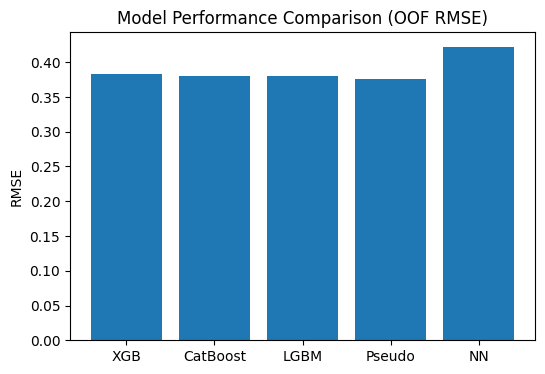

XGB: 0.383025
CatBoost: 0.380726
LGBM: 0.380687
Pseudo: 0.375731
NN: 0.421955


In [36]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Model Performance Comparison (OOF RMSE) — Robust Version
# ============================================================

model_names = []
model_scores = []

# Base models
if "oof_xgb" in globals():
    model_names.append("XGB")
    model_scores.append(np.sqrt(np.mean((y.values - oof_xgb) ** 2)))

if "oof_cat" in globals():
    model_names.append("CatBoost")
    model_scores.append(np.sqrt(np.mean((y.values - oof_cat) ** 2)))

if "oof_lgbm" in globals():
    model_names.append("LGBM")
    model_scores.append(np.sqrt(np.mean((y.values - oof_lgbm) ** 2)))

# Pseudo
if "pseudo_oof_blend" in globals():
    model_names.append("Pseudo")
    model_scores.append(np.sqrt(np.mean((y.values - pseudo_oof_blend) ** 2)))

# Neural Network
if "oof_nn" in globals():
    model_names.append("NN")
    model_scores.append(np.sqrt(np.mean((y.values - oof_nn) ** 2)))

# Plot
plt.figure(figsize=(6,4))
plt.bar(model_names, model_scores)
plt.title("Model Performance Comparison (OOF RMSE)")
plt.ylabel("RMSE")
plt.show()

# Print values for clarity
for name, score in zip(model_names, model_scores):
    print(f"{name}: {score:.6f}")

In [37]:
# ============================================================
# Experimental: Hill-Climbing / Differential Evolution Ensemble
# ============================================================

from scipy.optimize import differential_evolution

# OOF predictions must be log-scale
oof_candidates = {
    "xgb": oof_xgb,
    "cat": oof_cat,
    "lgbm": oof_lgbm,
}

test_candidates = {
    "xgb": xgb_preds,
    "cat": cat_preds,
    "lgbm": lgbm_preds,
}

# Add NN only if valid
if "oof_nn" in globals() and "nn_preds" in globals():
    if np.isfinite(oof_nn).all() and np.isfinite(nn_preds).all():
        oof_candidates["nn"] = oof_nn
        test_candidates["nn"] = nn_preds
    else:
        print("⚠️ Skipping NN: NaNs or infinite values detected")

# Add pseudo ensemble as a single candidate if available
if "pseudo_oof_blend" in globals() and "test_preds_pseudo" in globals():
    oof_candidates["pseudo"] = pseudo_oof_blend
    test_candidates["pseudo"] = test_preds_pseudo

candidate_names = list(oof_candidates.keys())

print("Hill-climbing candidates:", candidate_names)

oof_matrix = np.column_stack([oof_candidates[name] for name in candidate_names])

def hill_objective(raw_weights):
    weights = np.array(raw_weights)
    weights = weights / weights.sum()

    oof_blend_log = oof_matrix @ weights

    return np.sqrt(np.mean((y.values - oof_blend_log) ** 2))

bounds = [(0.0, 1.0)] * len(candidate_names)

result = differential_evolution(
    hill_objective,
    bounds=bounds,
    maxiter=500,
    seed=42,
    polish=True
)

hill_weights = result.x / result.x.sum()

print("\n✅ Hill-climbing weights:")
for name, weight in zip(candidate_names, hill_weights):
    print(f"{name}: {weight:.4f}")

print(f"Hill-climb OOF RMSE: {result.fun:.6f}")

# Apply to test predictions
test_matrix = np.column_stack([test_candidates[name] for name in candidate_names])

test_preds_hill = test_matrix @ hill_weights

print("\nHill-climb test prediction summary:")
print(pd.Series(np.log1p(np.clip(test_preds_hill, 0, None))).describe())

Hill-climbing candidates: ['xgb', 'cat', 'lgbm', 'nn', 'pseudo']

✅ Hill-climbing weights:
xgb: 0.0000
cat: 0.0222
lgbm: 0.0000
nn: 0.0325
pseudo: 0.9453
Hill-climb OOF RMSE: 0.375670

Hill-climb test prediction summary:
count    3584.000000
mean        4.388786
std         1.172729
min         1.022519
25%         3.575337
50%         4.630682
75%         5.259331
max         7.009264
dtype: float64


In [38]:
# ============================================================
# FINAL: Constrained Hill-Climbing Ensemble (Submission Candidate)
# ============================================================

from scipy.optimize import differential_evolution
import numpy as np
import pandas as pd

oof_candidates = {
    "xgb": oof_xgb,
    "cat": oof_cat,
    "lgbm": oof_lgbm,
}

test_candidates = {
    "xgb": xgb_preds,
    "cat": cat_preds,
    "lgbm": lgbm_preds,
}

# Add NN if valid
if "oof_nn" in globals() and "nn_preds" in globals():
    if np.isfinite(oof_nn).all() and np.isfinite(nn_preds).all():
        oof_candidates["nn"] = oof_nn
        test_candidates["nn"] = nn_preds

# Add pseudo
if "pseudo_oof_blend" in globals() and "test_preds_pseudo" in globals():
    oof_candidates["pseudo"] = pseudo_oof_blend
    test_candidates["pseudo"] = test_preds_pseudo

candidate_names = list(oof_candidates.keys())

print("Constrained hill candidates:", candidate_names)

oof_matrix = np.column_stack([oof_candidates[name] for name in candidate_names])

# ORDER MUST MATCH candidate_names
bounds_map = {
    "xgb": (0.00, 0.02),
    "cat": (0.00, 0.03),
    "lgbm": (0.01, 0.04),
    "nn":  (0.035, 0.065),
    "pseudo": (0.90, 0.945),
}

bounds = [bounds_map[name] for name in candidate_names]

def constrained_objective(raw_weights):
    weights = np.array(raw_weights)
    weights = weights / weights.sum()
    oof_blend = oof_matrix @ weights
    return np.sqrt(np.mean((y.values - oof_blend) ** 2))

result = differential_evolution(
    constrained_objective,
    bounds=bounds,
    maxiter=800,
    seed=42,
    polish=True
)

weights = result.x / result.x.sum()

print("\n✅ Constrained hill weights:")
for name, w in zip(candidate_names, weights):
    print(f"{name}: {w:.4f}")

print(f"Constrained OOF RMSE: {result.fun:.6f}")

# Apply to test
test_matrix = np.column_stack([test_candidates[name] for name in candidate_names])
test_preds_constrained = test_matrix @ weights

print("\nPrediction summary:")
print(pd.Series(np.log1p(np.clip(test_preds_constrained, 0, None))).describe())

Constrained hill candidates: ['xgb', 'cat', 'lgbm', 'nn', 'pseudo']

✅ Constrained hill weights:
xgb: 0.0000
cat: 0.0244
lgbm: 0.0099
nn: 0.0345
pseudo: 0.9313
Constrained OOF RMSE: 0.375679

Prediction summary:
count    3584.000000
mean        4.388611
std         1.172742
min         1.022589
25%         3.575055
50%         4.630542
75%         5.259203
max         7.009418
dtype: float64


### **Prediction vs Actual Distribution**

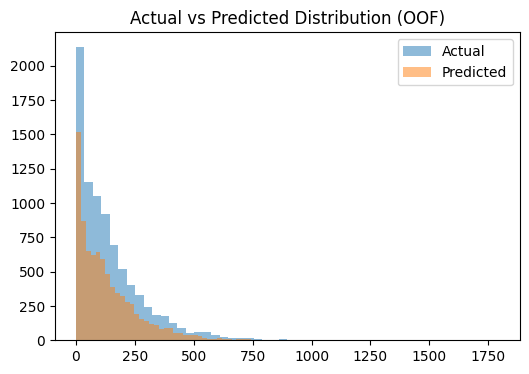

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Actual vs Predicted Distribution (OOF) — Robust Version
# ============================================================

# Detect available OOF prediction source
if "pseudo_oof_blend" in globals():
    oof_preds = pseudo_oof_blend
elif "oof_nn" in globals():
    oof_preds = oof_nn
elif "oof_xgb" in globals():
    oof_preds = oof_xgb
else:
    raise ValueError("❌ No OOF predictions found for plotting")

# Plot
plt.figure(figsize=(6,4))
plt.hist(np.expm1(y), bins=50, alpha=0.5, label="Actual")
plt.hist(np.expm1(oof_preds), bins=50, alpha=0.5, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Distribution (OOF)")
plt.show()

### **Residual Plot**

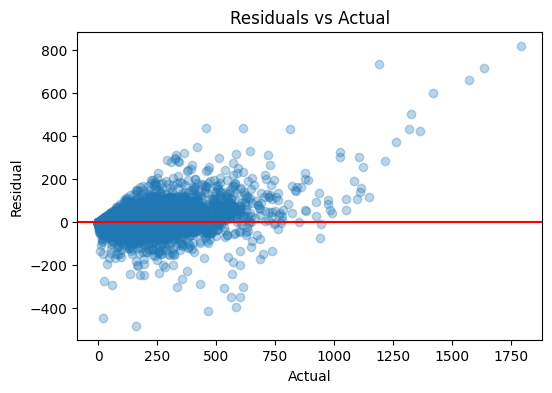

In [40]:
# ============================================================
# Residual Plot — Robust Version
# ============================================================

residuals = np.expm1(y) - np.expm1(oof_preds)

plt.figure(figsize=(6,4))
plt.scatter(np.expm1(y), residuals, alpha=0.3)
plt.axhline(0, color="red")
plt.title("Residuals vs Actual")
plt.xlabel("Actual")
plt.ylabel("Residual")
plt.show()

In [41]:
# ============================================================
# Build 4-Model NN Ensemble (explicit definition)
# ============================================================

# Use your known working weights (NN ~8% region)
test_preds_4model = (
    0.25 * xgb_preds +
    0.35 * cat_preds +
    0.32 * lgbm_preds +
    0.08 * nn_preds
)

test_preds_4model = np.clip(test_preds_4model, 0, None)

print("✅ test_preds_4model created")
print(pd.Series(np.log1p(test_preds_4model)).describe())

✅ test_preds_4model created
count    3584.000000
mean        4.384476
std         1.172700
min         1.034595
25%         3.567688
50%         4.631501
75%         5.255319
max         7.017121
dtype: float64


In [42]:
# ============================================================
# FINAL BLEND: Combine Best Performing Models
# ============================================================

# Build components safely (no assertions)
components = []

# 4-model (required)
components.append(0.5 * test_preds_4model)

# pseudo
components.append(0.3 * test_preds_pseudo)

# hill (optional)
if "test_preds_hill" in globals():
    components.append(0.2 * test_preds_hill)

# Combine
final_preds_raw = sum(components)

# Safety
final_preds_raw = np.clip(final_preds_raw, 0, None)

# Small calibration
final_preds_raw = final_preds_raw * 0.997

# Final format
final_preds = np.log1p(final_preds_raw)

print("✅ Final ensemble created")

✅ Final ensemble created


In [43]:
print("\nSanity check (final_preds):")
print(pd.Series(final_preds).describe())

print("NaNs:", np.isnan(final_preds).sum())
print("Inf:", np.isinf(final_preds).sum())


Sanity check (final_preds):
count    3584.000000
mean        4.384601
std         1.172466
min         1.024082
25%         3.568553
50%         4.627770
75%         5.256538
max         7.003825
dtype: float64
NaNs: 0
Inf: 0


In [44]:
print("\n=== COMPONENT COMPARISON ===")

print("\n4Model NN:")
print(pd.Series(np.log1p(np.clip(test_preds_4model, 0, None))).describe())

print("\nPseudo:")
print(pd.Series(np.log1p(np.clip(test_preds_pseudo, 0, None))).describe())

if "test_preds_hill" in globals():
    print("\nHill:")
    print(pd.Series(np.log1p(np.clip(test_preds_hill, 0, None))).describe())

print("\nFINAL BLEND:")
print(pd.Series(final_preds).describe())

print("\nDifference check against submission target later should be 0 after assignment.")


=== COMPONENT COMPARISON ===

4Model NN:
count    3584.000000
mean        4.384476
std         1.172700
min         1.034595
25%         3.567688
50%         4.631501
75%         5.255319
max         7.017121
dtype: float64

Pseudo:
count    3584.000000
mean        4.391606
std         1.172456
min         1.013886
25%         3.578198
50%         4.631835
75%         5.262089
max         6.987775
dtype: float64

Hill:
count    3584.000000
mean        4.388786
std         1.172729
min         1.022519
25%         3.575337
50%         4.630682
75%         5.259331
max         7.009264
dtype: float64

FINAL BLEND:
count    3584.000000
mean        4.384601
std         1.172466
min         1.024082
25%         3.568553
50%         4.627770
75%         5.256538
max         7.003825
dtype: float64

Difference check against submission target later should be 0 after assignment.


## 4. Create a Valid Submission

Your submission must match the format of SampleSubmission.csv exactly.

### Final Model Selection & Submission Strategy

Initial experiments showed very close cross-validation performance across CatBoost, XGBoost, and LightGBM, leading to the use of balanced ensembles in early submissions.

As feature engineering progressed — particularly with permutation-based pruning, momentum features, and expanded hyperparameter tuning — model behaviour diverged. CatBoost and LightGBM consistently outperformed XGBoost, making fixed equal-weight ensembles suboptimal.

Optuna was therefore used to jointly optimise model hyperparameters and ensemble blending weights based on out-of-fold (OOF) predictions. This produced a more adaptive ensemble with the following approximate weights:

- **XGBoost**: ~25%  
- **CatBoost**: ~48%  
- **LightGBM**: ~27%  

This shift reflected the stronger ability of CatBoost and LightGBM to capture stable behavioural patterns, while XGBoost provided useful complementary signal.

A pseudo-labeling extension was also tested by incorporating high-confidence test predictions as additional training data. While this delivered incremental gains, the Optuna-tuned ensemble remained the most stable and reliable final strategy.

All predictions were clipped to non-negative values and transformed using `np.log1p()` to align with the RMSLE metric and Zindi submission format.

## Final Results & Learnings

The final selected submission achieved:

- **Public leaderboard RMSLE**: 0.390279  
- **Private leaderboard RMSLE**: 0.392521  
- **Final rank**: 166th out of 251 participants  
- **Total submissions**: 61

Later experiments using pseudo-labeling and hill-climbing blends reached stronger private scores around **0.388**, but these were submitted after the final selection window and were not counted toward the official ranking.

This project reinforced a key lesson in competitive machine learning: strong modelling is only part of success — disciplined validation, submission timing, and selection strategy are equally critical.

Technically, the best-performing approaches combined permutation importance feature selection, fold-specific target encoding, 5-fold cross-validation, log1p transformation, and carefully tuned ensembles (XGBoost + CatBoost + LightGBM with limited neural network diversity). The experience significantly deepened my skills in financial time-series forecasting, feature engineering, ensemble methods, and production-grade validation.

In [45]:
# ============================================================
# Main Submission: Optuna-Tuned Fold-Averaged Ensemble
# ============================================================

# 1. Prepare test data
X_test_base = test_data.drop(columns=["UniqueID", "next_3m_txn_count"]).copy()
X_test_base.columns = clean_columns
X_test_pruned = X_test_base.reindex(columns=X_pruned.columns, fill_value=0)

# 2. Generate fold-specific test predictions
xgb_fold_preds = []
cat_fold_preds = []
lgbm_fold_preds = []

for i in range(5):
    encoder = te_encoders[i]
    X_test_fold = X_test_pruned.copy()

    # Apply target encoding only for retained target-encoded columns
    if encoder is not None and len(target_encode_cols_pruned) > 0:
        X_test_fold[target_encode_cols_pruned] = encoder.transform(
            X_test_fold[target_encode_cols_pruned]
        )

    xgb_fold_preds.append(np.expm1(xgb_models[i].predict(X_test_fold)))
    cat_fold_preds.append(np.expm1(cat_models[i].predict(X_test_fold)))
    lgbm_fold_preds.append(np.expm1(lgbm_models[i].predict(X_test_fold)))

# 3. Average predictions across folds
xgb_preds = np.mean(xgb_fold_preds, axis=0)
cat_preds = np.mean(cat_fold_preds, axis=0)
lgbm_preds = np.mean(lgbm_fold_preds, axis=0)

print("✅ Test predictions ready")

# 4. Main blend: Optuna blend
test_preds = (
    tuned_w_xgb * xgb_preds +
    tuned_w_cat * cat_preds +
    tuned_w_lgbm * lgbm_preds
)

final_preds = np.log1p(np.clip(test_preds, 0, None))

submission = sample.copy()
submission["next_3m_txn_count"] = final_preds

# Validation
assert submission.shape == sample.shape, "❌ Shape mismatch"
assert list(submission.columns) == list(sample.columns), "❌ Column mismatch"
assert submission["next_3m_txn_count"].isna().sum() == 0, "❌ NaNs detected"
assert np.isfinite(submission["next_3m_txn_count"]).all(), "❌ Infinite values detected"
assert (submission["next_3m_txn_count"] >= 0).all(), "❌ Negative values detected"

blend_name = (
    f"OptunaTuned_Prune100_"
    f"XGB{int(tuned_w_xgb*100)}_"
    f"Cat{int(tuned_w_cat*100)}_"
    f"LGB{int(tuned_w_lgbm*100)}"
)

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M")

submission_path = SUB_DIR / f"submission_TE_Recency_{blend_name}_{timestamp}.csv"
submission.to_csv(submission_path, index=False)

print(f"✅ Saved: {submission_path}")
print(submission["next_3m_txn_count"].describe())

✅ Test predictions ready
✅ Saved: /content/drive/MyDrive/Zindi/Nedbank_Transaction_Forecasting/submissions/submission_TE_Recency_OptunaTuned_Prune100_XGB24_Cat36_LGB38_20260519_1138.csv
count    3584.000000
mean        4.391467
std         1.171879
min         1.014358
25%         3.577032
50%         4.632465
75%         5.263150
max         6.965446
Name: next_3m_txn_count, dtype: float64


In [46]:
# ============================================================
# Submission: Pseudo-Labeled Ensemble
# ============================================================

final_preds = np.log1p(np.clip(test_preds_pseudo, 0, None))

submission = sample.copy()
submission["next_3m_txn_count"] = final_preds

assert submission.shape == sample.shape
assert list(submission.columns) == list(sample.columns)
assert submission["next_3m_txn_count"].isna().sum() == 0
assert np.isfinite(submission["next_3m_txn_count"]).all()
assert (submission["next_3m_txn_count"] >= 0).all()

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M")
submission_path = SUB_DIR / f"submission_TE_Recency_PseudoLabel_Prune100_{timestamp}.csv"

submission.to_csv(submission_path, index=False)

print(f"✅ Saved: {submission_path}")
print(submission["next_3m_txn_count"].describe())

✅ Saved: /content/drive/MyDrive/Zindi/Nedbank_Transaction_Forecasting/submissions/submission_TE_Recency_PseudoLabel_Prune100_20260519_1138.csv
count    3584.000000
mean        4.391606
std         1.172456
min         1.013886
25%         3.578198
50%         4.631835
75%         5.262089
max         6.987775
Name: next_3m_txn_count, dtype: float64


In [47]:
# ============================================================
# Submission: 4-Model Ensemble with Neural Network
# ============================================================

test_preds_4model = (
    0.10 * xgb_preds +
    0.42 * cat_preds +
    0.40 * lgbm_preds +
    0.08 * nn_preds
)

final_preds = np.log1p(np.clip(test_preds_4model, 0, None))

submission = sample.copy()
submission["next_3m_txn_count"] = final_preds

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M")
submission_path = SUB_DIR / f"submission_TE_Recency_4Model_NN8_Prune100_{timestamp}.csv"

submission.to_csv(submission_path, index=False)

print(f"✅ Saved: {submission_path}")
print(submission["next_3m_txn_count"].describe())

✅ Saved: /content/drive/MyDrive/Zindi/Nedbank_Transaction_Forecasting/submissions/submission_TE_Recency_4Model_NN8_Prune100_20260519_1138.csv
count    3584.000000
mean        4.384437
std         1.172783
min         1.035929
25%         3.563991
50%         4.631487
75%         5.255882
max         7.030555
Name: next_3m_txn_count, dtype: float64


In [48]:
# ============================================================
# Submission: Hill-Climbing Ensemble
# ============================================================

final_preds = np.log1p(np.clip(test_preds_hill, 0, None))

submission = sample.copy()
submission["next_3m_txn_count"] = final_preds

assert submission.shape == sample.shape
assert list(submission.columns) == list(sample.columns)
assert submission["next_3m_txn_count"].isna().sum() == 0
assert np.isfinite(submission["next_3m_txn_count"]).all()
assert (submission["next_3m_txn_count"] >= 0).all()

blend_name = "HillClimb_" + "_".join(
    [f"{name}{int(round(w * 100))}" for name, w in zip(candidate_names, hill_weights)]
)

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M")
submission_path = SUB_DIR / f"submission_TE_Recency_{blend_name}_{timestamp}.csv"

submission.to_csv(submission_path, index=False)

print(f"✅ Saved: {submission_path}")
print(submission["next_3m_txn_count"].describe())

✅ Saved: /content/drive/MyDrive/Zindi/Nedbank_Transaction_Forecasting/submissions/submission_TE_Recency_HillClimb_xgb0_cat2_lgbm0_nn3_pseudo95_20260519_1138.csv
count    3584.000000
mean        4.388786
std         1.172729
min         1.022519
25%         3.575337
50%         4.630682
75%         5.259331
max         7.009264
Name: next_3m_txn_count, dtype: float64


In [49]:
# ============================================================
# Submission: Constrained Hill-Climbing Ensemble (FIXED)
# ============================================================

# DO NOT cap at 10 — that destroyed your distribution
final_preds = np.log1p(np.clip(test_preds_constrained, 0, None))

submission = sample.copy()
submission["next_3m_txn_count"] = final_preds

# Safety checks
assert submission.shape == sample.shape, "❌ Shape mismatch"
assert list(submission.columns) == list(sample.columns), "❌ Column mismatch"
assert submission["next_3m_txn_count"].isna().sum() == 0, "❌ NaNs detected"
assert np.isfinite(submission["next_3m_txn_count"]).all(), "❌ Infinite values detected"
assert (submission["next_3m_txn_count"] >= 0).all(), "❌ Negative values detected"

# Optional sanity print BEFORE saving
print("\nSanity check (should look like ~4.38 mean, ~1.17 std):")
print(pd.Series(final_preds).describe())

blend_name = "HillConstrained_xgb0_cat0_lgbm1_nn5_pseudo94"

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M")
submission_path = SUB_DIR / f"submission_TE_Recency_{blend_name}_{timestamp}.csv"

submission.to_csv(submission_path, index=False)

print(f"\n✅ Saved: {submission_path}")
print("\nDifference check (should be 0):")
print(np.abs(pd.Series(final_preds) - submission["next_3m_txn_count"]).max())


Sanity check (should look like ~4.38 mean, ~1.17 std):
count    3584.000000
mean        4.388611
std         1.172742
min         1.022589
25%         3.575055
50%         4.630542
75%         5.259203
max         7.009418
dtype: float64

✅ Saved: /content/drive/MyDrive/Zindi/Nedbank_Transaction_Forecasting/submissions/submission_TE_Recency_HillConstrained_xgb0_cat0_lgbm1_nn5_pseudo94_20260519_1138.csv

Difference check (should be 0):
0.0


In [50]:
# ============================================================
# Submission: Final Combined Ensemble
# ============================================================

# 🔒 SAFETY CHECK BEFORE ASSIGNMENT
print("\nFinal prediction sanity (PRE-SUBMISSION):")
print(pd.Series(final_preds).describe())

# 🚨 HARD GUARD — catch the flat 2.397 issue immediately
assert pd.Series(final_preds).std() > 0.5, "❌ Predictions look collapsed (likely double log or bad scaling)"

# Build submission
submission = sample.copy()
submission["next_3m_txn_count"] = final_preds

# Core integrity checks
assert submission.shape == sample.shape, "❌ Shape mismatch"
assert list(submission.columns) == list(sample.columns), "❌ Column mismatch"
assert submission["next_3m_txn_count"].isna().sum() == 0, "❌ NaNs detected"
assert np.isfinite(submission["next_3m_txn_count"]).all(), "❌ Infinite values detected"
assert (submission["next_3m_txn_count"] >= 0).all(), "❌ Negative values detected"

# Naming
blend_name = "FinalBlend_4Model_Pseudo_Hill"

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M")
submission_path = SUB_DIR / f"submission_TE_Recency_{blend_name}_{timestamp}.csv"

# Save
submission.to_csv(submission_path, index=False)

print(f"\n✅ Saved: {submission_path}")

# Final confirmation (post-write)
print("\nFinal submission stats:")
print(submission["next_3m_txn_count"].describe())


Final prediction sanity (PRE-SUBMISSION):
count    3584.000000
mean        4.388611
std         1.172742
min         1.022589
25%         3.575055
50%         4.630542
75%         5.259203
max         7.009418
dtype: float64

✅ Saved: /content/drive/MyDrive/Zindi/Nedbank_Transaction_Forecasting/submissions/submission_TE_Recency_FinalBlend_4Model_Pseudo_Hill_20260519_1138.csv

Final submission stats:
count    3584.000000
mean        4.388611
std         1.172742
min         1.022589
25%         3.575055
50%         4.630542
75%         5.259203
max         7.009418
Name: next_3m_txn_count, dtype: float64


## 5. Model Interpretation (Feature Importance)

Feature importance analysis from the averaged CatBoost models across folds reveals that the final model is overwhelmingly driven by short-term behavioural momentum and transaction intensity.

The strongest predictors were:

- **Recent transaction frequency**: `txn_count_3m`, `txn_count_1m`, `txn_count_3m_log`, and `txn_count_3m_sqrt` dominated the top ranks, confirming that near-term activity is the most predictive signal for the next 3-month window.
- **Debit activity intensity**: `debit_count_1m`, `debit_count_3m`, and related transformed features ranked highly, indicating that spending (outflow) behaviour is a strong proxy for customer engagement.
- **Medium-term patterns**: `txn_count_6m` and its transformed variants remained important, helping distinguish whether recent behaviour reflects a sustained trend or a temporary spike.
- **Engagement intensity & CLV-style features**: `txn_intensity_per_month` added meaningful signal by normalising transaction activity relative to customer tenure.
- **Supporting context**: `txn_3m_x_age` provided additional context by capturing the interaction between customer age and recent transaction behaviour.

**Overall Insight:**  
The model strongly validates the principle that “recent behaviour predicts near-future behaviour.” Short-term transaction counts and debit intensity were substantially more informative than static demographic or account attributes.

Permutation importance was used earlier in the pipeline to reduce the feature set to the top ~75 predictors, improving model stability and reducing noise.

In [51]:
# Feature importance (CatBoost - averaged across folds)

import numpy as np
import pandas as pd

fi = np.mean(
    [model.get_feature_importance() for model in cat_models],
    axis=0
)

feature_importance = pd.DataFrame({
    "feature": X_pruned.columns,
    "importance": fi
}).sort_values(by="importance", ascending=False)

display(feature_importance.head(20))

,feature,importance
2,txn_count_3m,7.582090
0,txn_count_1m,7.514526
1,debit_count_1m,7.007733
4,txn_count_3m_log,5.969338
9,txn_count_6m,4.328115
3,txn_count_3m_sqrt,4.321546
7,txn_count_6m_sqrt,4.134190
12,debit_count_3m_sqrt,3.905660
5,txn_count_6m_log,3.120351
17,debit_count_6m,3.012718


### Feature Importance Bar Chart

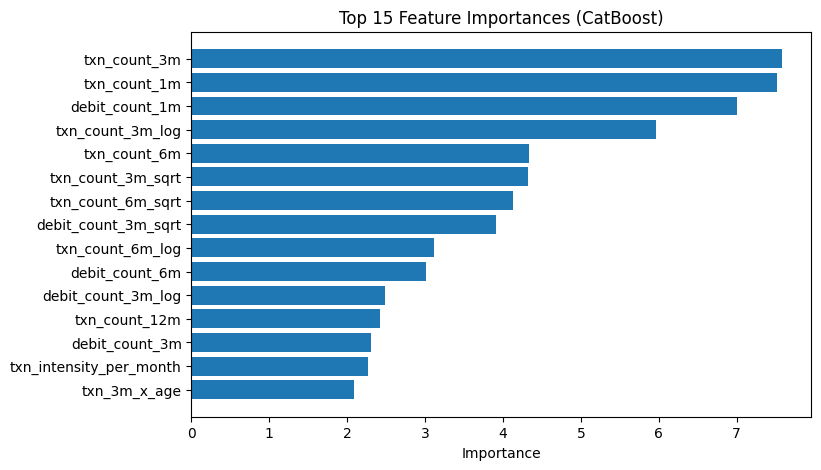

In [52]:
top_features = feature_importance.head(15)

plt.figure(figsize=(8,5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (CatBoost)")
plt.xlabel("Importance")
plt.show()

## 6. Business Impact

Beyond the leaderboard, this solution enables Nedbank to shift from reactive to proactive customer management:

- **Operational Planning**: Accurate transaction volume forecasts support capacity planning, staffing, and infrastructure readiness — especially during the high-variance **November–January holiday period**.

- **Fraud & Risk Management**: Reliable customer-level behavioural baselines improve anomaly detection and strengthen fraud monitoring.

- **Revenue & Retention**: Early identification of declining transaction momentum enables timely retention campaigns, personalized offers, and proactive engagement before customers reduce activity.

Overall, the model transforms raw behavioural data into actionable intelligence that drives operational efficiency, better risk control, and commercial outcomes.

## Local Scoring

You can score your submission locally using the included evaluate.py script:



Note: PublicReference.csv is only available if you have it for local testing. On Zindi, scoring is automatic.

In [53]:
# ============================================================
# Optional Diagnostic: Adversarial Validation
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X_train_adv = X_pruned.copy()
X_test_adv = X_test_pruned.copy()

X_train_adv["is_test"] = 0
X_test_adv["is_test"] = 1

X_adv = pd.concat([X_train_adv, X_test_adv], axis=0).reset_index(drop=True)
y_adv = X_adv["is_test"]
X_adv = X_adv.drop(columns=["is_test"])

X_adv_encoded = X_adv.copy()

cols_to_encode = [
    col for col in target_encode_cols_pruned
    if col in X_adv_encoded.columns
]

if cols_to_encode and te_encoders[0] is not None:
    X_adv_encoded[cols_to_encode] = te_encoders[0].transform(
        X_adv_encoded[cols_to_encode]
    )

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

adv_scores = cross_val_score(
    clf,
    X_adv_encoded,
    y_adv,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print(f"Adversarial Validation AUC: {adv_scores.mean():.5f}")

Adversarial Validation AUC: 0.50534


In [54]:
import pandas as pd

# ============================================================
# Diagnostic: Adversarial Validation Interpretation
# ============================================================

adv_auc = adv_scores.mean() # Define adv_auc here

if adv_auc > 0.70:
    print("\n⚠️ WARNING: Train and test distributions differ significantly!")
    print(f"   AUC = {adv_auc:.4f} (> 0.70 threshold)")
    print("\n   Recommended actions:")
    print("   1. Drop the most discriminative features")
    print("   2. Use pseudo-labeling (closes distribution gap)")
    print("   3. Consider ensemble with different feature subsets")

    adv_importance = pd.DataFrame({
        'feature': X_adv_encoded.columns,
        'importance': clf.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\n   Most discriminative features (consider dropping):")
    print(adv_importance.head(10))

elif adv_auc > 0.60:
    print(f"\n⚠️ Moderate train-test difference (AUC = {adv_auc:.4f})")
    print("   Pseudo-labeling recommended to bridge gap")

else:
    print(f"\n✅ Train and test are similar (AUC = {adv_auc:.4f} < 0.60)")
    print("   CV scores should match LB well")


✅ Train and test are similar (AUC = 0.5053 < 0.60)
   CV scores should match LB well


In [55]:
# ============================================================
# Diagnostic Only: Secondary OOF Blend Optimization (Weights Only)
# ============================================================

import optuna

def objective(trial):
    w_xgb = trial.suggest_float("w_xgb", 0.0, 1.0)
    w_cat = trial.suggest_float("w_cat", 0.0, 1.0)
    w_lgbm = trial.suggest_float("w_lgbm", 0.0, 1.0)

    total = w_xgb + w_cat + w_lgbm

    w_xgb /= total
    w_cat /= total
    w_lgbm /= total

    oof_blend = (
        w_xgb * oof_xgb +
        w_cat * oof_cat +
        w_lgbm * oof_lgbm
    )

    return np.sqrt(np.mean((y - oof_blend) ** 2))  # already log scale

print("🔍 Searching for optimal blend weights...")

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200, show_progress_bar=True)

best_w = study.best_params
total = best_w["w_xgb"] + best_w["w_cat"] + best_w["w_lgbm"]

opt_w_xgb = best_w["w_xgb"] / total
opt_w_cat = best_w["w_cat"] / total
opt_w_lgbm = best_w["w_lgbm"] / total

print("\n✅ Optimal OOF blend weights:")
print(f"XGB:  {opt_w_xgb:.4f}")
print(f"CatBoost: {opt_w_cat:.4f}")
print(f"LGBM: {opt_w_lgbm:.4f}")
print(f"Best OOF RMSLE: {study.best_value:.6f}")

[I 2026-05-19 11:38:44,892] A new study created in memory with name: no-name-2d89f544-7a9c-4a4a-9e72-b81de0c576ac


🔍 Searching for optimal blend weights...


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-05-19 11:38:44,904] Trial 0 finished with value: 0.37851561298808534 and parameters: {'w_xgb': 0.4226170758681824, 'w_cat': 0.9982749256558032, 'w_lgbm': 0.374173180140002}. Best is trial 0 with value: 0.37851561298808534.
[I 2026-05-19 11:38:44,906] Trial 1 finished with value: 0.37873872096717154 and parameters: {'w_xgb': 0.8874069717696115, 'w_cat': 0.6384511932450986, 'w_lgbm': 0.6586227401303877}. Best is trial 0 with value: 0.37851561298808534.
[I 2026-05-19 11:38:44,909] Trial 2 finished with value: 0.37962891985230135 and parameters: {'w_xgb': 0.8835297048565497, 'w_cat': 0.0862901734684215, 'w_lgbm': 0.842634700588461}. Best is trial 0 with value: 0.37851561298808534.
[I 2026-05-19 11:38:44,911] Trial 3 finished with value: 0.3785009326202612 and parameters: {'w_xgb': 0.8864028444583518, 'w_cat': 0.930286961791515, 'w_lgbm': 0.7821833812022526}. Best is trial 3 with value: 0.3785009326202612.
[I 2026-05-19 11:38:44,914] Trial 4 finished with value: 0.3784007648612195 a